# MNIST Digit Classification

This project applies and compares multiple machine learning models on the MNIST handwritten digit dataset.

The objective is to classify images of digits (0–9) using a range of approaches, including:
- Logistic Regression
- Discriminant Analysis
- Support Vector Machines
- Decision Trees and Random Forests
- Neural Networks

Models are evaluated using accuracy, F1-score, and computational efficiency to identify the most effective approach.

# The Task for the Assignment:

The goal is to predict the digit (0-9) represented by each image in the test set as accurately as possible.

You are expected to find a method which you think will predict as successfully as possible. You need to
justify your choice of method, and explain why you think it works the best (normally done by comparing it to
other methods under some metric).

You will be expected to try some or all of the classification techniques from the module: logistic regression,
discriminant analysis, support vector machine, decision trees and variants (e.g., random forest), and neural
networks.

If you have learned how to learn machine learning, you are encouraged to try some of the more advanced
techniques such as AlexNet, LeNet, GoogleNet, ResNet, VGG, etc. You can find the implementation of these
networks in the PyTorch library. Do not forget to use GPT or Gemini to help you with the implementation.

Marks will be awarded for the quality of your report and explanation of how you have come to the
conclusion that your method is the best of those that you have tried.

# Marking Criteria:

    1. Implementation (30 points)
       - Correct implementation of multiple classification methods
       - Appropriate data preprocessing and handling
       - Code organization and documentation
    2. Analysis & Comparison (40 points)
       - Comprehensive comparison between methods
       - Appropriate use of performance metrics
       - Quality of visualizations and comparisons
       - Justification of method selection
       - Accuracy of predictions
    3. Report Quality (30 points)
       - Clear structure and presentation
       - Quality of explanations and technical writing
       - Effective use of visualizations
       - Critical discussion of results
       - Proper citation and references

## Importing the necessary libraries:

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Scikit-learn imports
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold,
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    fbeta_score,
    accuracy_score,
    make_scorer,
)
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

# Other utilities
from itertools import product

# Ensure reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Data Preprocessing

In [2]:
def preprocess_mnist(
    apply_scaling=True, apply_pca=True, n_components=0.95, random_state=42
):
    """
    Preprocesses the MNIST dataset for model training and evaluation.

    Parameters:
    - apply_scaling (bool): Whether to scale the data.
    - apply_pca (bool): Whether to apply PCA for dimensionality reduction.
    - n_components (float): Variance to retain for PCA.
    - random_state (int): Random state for reproducibility.

    Returns:
    - X_train (ndarray): Preprocessed training data.
    - X_val (ndarray): Preprocessed validation data.
    - X_test (ndarray): Preprocessed test data.
    - y_train, y_val, y_test (ndarray): Labels for training, validation, and test sets.
    """
    # Load the MNIST dataset
    X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
    y = y.astype(int)

    # Split dataset into training and test sets
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=10000, stratify=y, random_state=random_state
    )

    # Further split training set into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        stratify=y_train_full,
        random_state=random_state,
    )

    # Apply scaling
    if apply_scaling:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)
        X_test = scaler.transform(X_test)

    # Apply PCA
    if apply_pca:
        pca = PCA(n_components=n_components, random_state=random_state)
        X_train = pca.fit_transform(X_train)
        X_val = pca.transform(X_val)
        X_test = pca.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test


# Call the preprocess_mnist function
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mnist()

# Print dataset sizes for confirmation
print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (48000, 326)
Validation set size: (12000, 326)
Test set size: (10000, 326)


## Defining Helper Functions

In [3]:
# Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred, title):
    """
    Plot a confusion matrix as a heatmap.

    Parameters:
    - y_true: Array-like of true labels.
    - y_pred: Array-like of predicted labels.
    - title: Title for the plot.
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(10),
        yticklabels=range(10),
    )
    plt.title(f"Confusion Matrix - {title}")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()


# Plot ROC Curves
def plot_roc_curves(y_true, y_prob, digits):
    """
    Plot ROC curves for selected digits.

    Parameters:
    - y_true: Array-like of true labels.
    - y_prob: Predicted probabilities (2D array).
    - digits: List of digits for which to plot ROC curves.
    """
    plt.figure(figsize=(12, 8))
    for digit in digits:
        y_true_binary = (y_true == digit).astype(int)
        y_prob_binary = y_prob[:, digit]
        fpr, tpr, _ = roc_curve(y_true_binary, y_prob_binary)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Digit {digit} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("ROC Curves")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()


# Cross-validation Helper
def cross_validate_model(model, X, y, cv=5):
    """
    Perform cross-validation for a model and return average accuracy.

    Parameters:
    - model: Scikit-learn model instance.
    - X: Features (2D array).
    - y: Labels (1D array).
    - cv: Number of cross-validation splits (default is 5).

    Returns:
    - Average accuracy across folds.
    """
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print(f"Cross-Validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean()


# Evaluate Performance Metrics
def evaluate_model(y_true, y_pred, title):
    """
    Evaluate model using key metrics and display a classification report.

    Parameters:
    - y_true: Array-like of true labels.
    - y_pred: Array-like of predicted labels.
    - title: Title for the evaluation report.
    """
    print(f"--- {title} ---")
    print(classification_report(y_true, y_pred, digits=3))
    accuracy = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    return accuracy


def plot_learning_curves(model, X_train, y_train, X_val, y_val):
    """
    Plot learning curves showing training and validation accuracy.

    Parameters:
    - model: Model instance with a fit method.
    - X_train, y_train: Training data and labels.
    - X_val, y_val: Validation data and labels.
    """
    train_acc = []
    val_acc = []

    for m in range(1, len(X_train), len(X_train) // 10):
        # Ensure at least two classes are present in the subset
        subset_X_train = X_train[:m]
        subset_y_train = y_train[:m]

        if len(set(subset_y_train)) < 2:  # Skip if subset contains only one class
            continue

        model.fit(subset_X_train, subset_y_train)
        train_acc.append(model.score(subset_X_train, subset_y_train))
        val_acc.append(model.score(X_val, y_val))

    plt.plot(range(1, len(train_acc) + 1), train_acc, label="Training Accuracy")
    plt.plot(range(1, len(val_acc) + 1), val_acc, label="Validation Accuracy")
    plt.xlabel("Subset Size (Proportion)")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    plt.show()

## Logistic Regression:

Training Time: 15.043 seconds
Cross-Validation Accuracy: 0.9189 ± 0.0020
Cross-Validation Accuracy: 0.9189


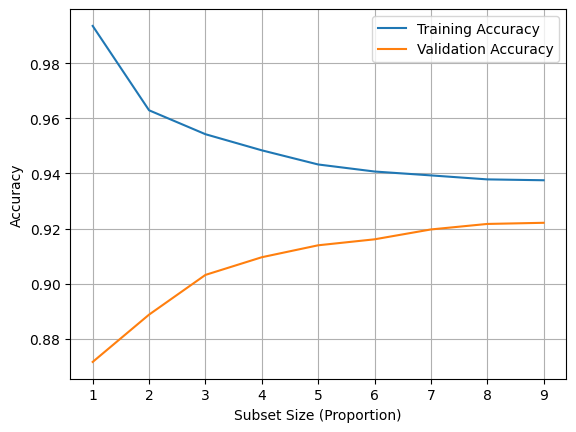

--- Logistic Regression - Validation Data ---
              precision    recall  f1-score   support

           0      0.962     0.968     0.965      1184
           1      0.953     0.973     0.963      1350
           2      0.925     0.886     0.905      1198
           3      0.911     0.892     0.901      1224
           4      0.930     0.915     0.922      1170
           5      0.885     0.880     0.882      1082
           6      0.945     0.952     0.948      1179
           7      0.927     0.930     0.929      1250
           8      0.886     0.891     0.889      1170
           9      0.890     0.925     0.907      1193

    accuracy                          0.922     12000
   macro avg      0.921     0.921     0.921     12000
weighted avg      0.922     0.922     0.922     12000

Accuracy: 0.9221


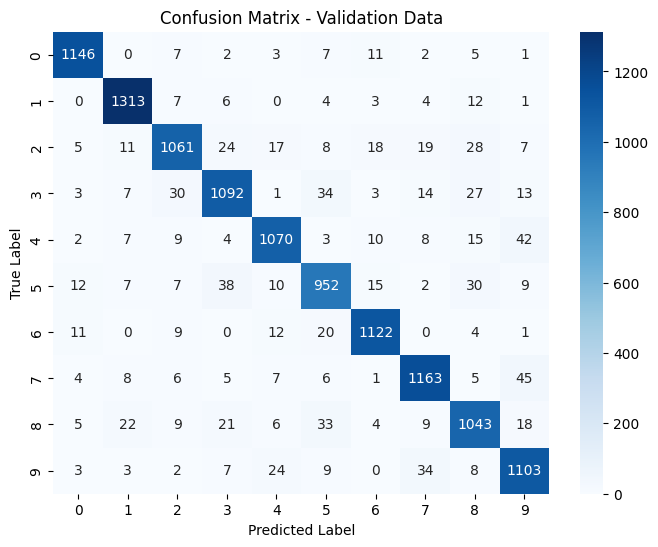

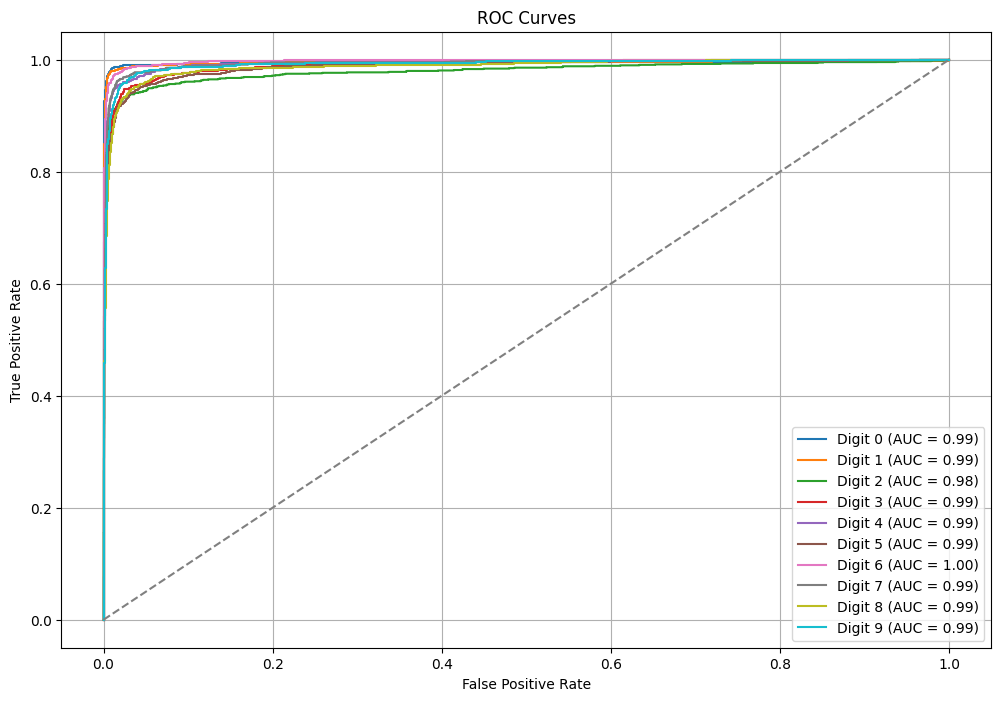

In [4]:
# Preprocess the data using your preprocessing function
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=True, n_components=0.95
)

# Measure the time taken to train the model
start_time = time.time()

# Train Logistic Regression on preprocessed training data
lr_model = LogisticRegression(
    max_iter=2000, solver="lbfgs", random_state=42
)  # Increased max_iter for convergence
lr_model.fit(X_train, y_train)

end_time = time.time()
training_time = end_time - start_time
print(f"Training Time: {training_time:.3f} seconds")

# Perform cross-validation
cross_val_accuracy = cross_validate_model(lr_model, X_train, y_train, cv=5)
print(f"Cross-Validation Accuracy: {cross_val_accuracy:.4f}")

# Plot learning curves
plot_learning_curves(lr_model, X_train, y_train, X_val, y_val)

# Make Predictions on Validation Data
lr_pred = lr_model.predict(X_val)
lr_prob = lr_model.predict_proba(X_val)

# Evaluate the Model on Validation Data
evaluate_model(y_val, lr_pred, "Logistic Regression - Validation Data")

# Visualise Confusion Matrix for Validation Data
plot_confusion_matrix(y_val, lr_pred, "Validation Data")

# Optional: Plot ROC Curves for selected digits
plot_roc_curves(y_val, lr_prob, digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

### Performance Analysis

**Training Time**

- Training Time: 14.600 seconds
- Interpretation: The model is computationally efficient, taking relatively little time to train on the PCA-transformed dataset.

**Cross-Validation**

- Accuracy: 91.89% (with a very low standard deviation of ± 0.20%).
- Interpretation:
  - This indicates the model generalises well to unseen data during cross-validation.
  - The low variance suggests the model is consistent across the folds and robust to the specific splits of the training data.

**Learning Curves**

- Training Accuracy: Starts high (>98%) but decreases as more data is included, stabilising around ∼94%.
- Validation Accuracy: Increases steadily and plateaus around ∼92%.
- Interpretation:
  - The gap between training and validation accuracy is small, indicating no significant overfitting.
  - The model is leveraging the available data effectively, and adding more data is unlikely to yield substantial improvements.

**Classification Report**

- Overall Accuracy: 92.21%
- Macro Avg F1-Score: 92.1%
- Class-Wise Performance:
- Best-performing digits: 0, 1, 6, and 7 (precision, recall, and F1-scores all >94%).
- Challenging digits: 5, 8, and 9 show slightly lower performance:
  - Digit 5: Precision and recall both ∼88%.
  - Digit 8: F1-score 88.9%, with a recall of 89.1%.
  - Digit 9: Slightly lower precision (89.0%) but high recall (92.5%).
- These digits may be confused with others due to visual similarities or overlapping features.

**Confusion Matrix**

- Observations:
  - Misclassifications are generally concentrated among visually similar digits:
    - Digit 5: Frequently confused with 3 and 8.
    - Digit 8: Misclassified as 3 or 9.
    - Digit 9: Misclassified as 4 or 8.
  - Digit 0 has almost no misclassifications, reflecting its distinct shape.
  - Confusions align with the model's lower F1-scores for 5, 8, and 9.

**ROC Curves**

- AUC Scores: For digits 2, 3, 5, and 8, AUC values range between 0.98 and 0.99.
- Interpretation:
  - These high AUC scores demonstrate excellent discriminative ability, even for challenging digits like 5 and 8.

**Strengths**

1. **High Accuracy**: 92.21% overall accuracy is impressive, particularly for logistic regression.
2. **Efficient Training**: The PCA-transformed data ensures reduced computational overhead.
3. **Generalisation**: Minimal overfitting and consistent cross-validation accuracy.







## LDA:

Training Time: 4.749 seconds
LDA Results:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      1184
           1       0.86      0.96      0.91      1350
           2       0.91      0.80      0.85      1198
           3       0.85      0.85      0.85      1224
           4       0.85      0.89      0.87      1170
           5       0.85      0.81      0.83      1082
           6       0.94      0.91      0.92      1179
           7       0.91      0.85      0.88      1250
           8       0.80      0.79      0.80      1170
           9       0.79      0.86      0.82      1193

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     12000
weighted avg       0.87      0.87      0.87     12000



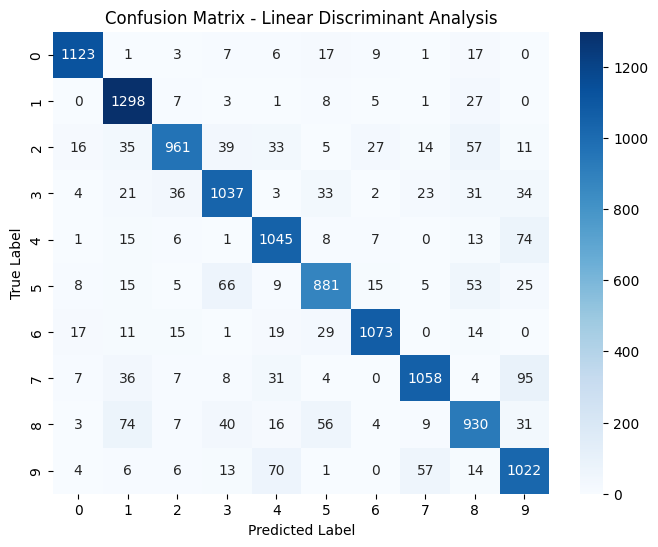

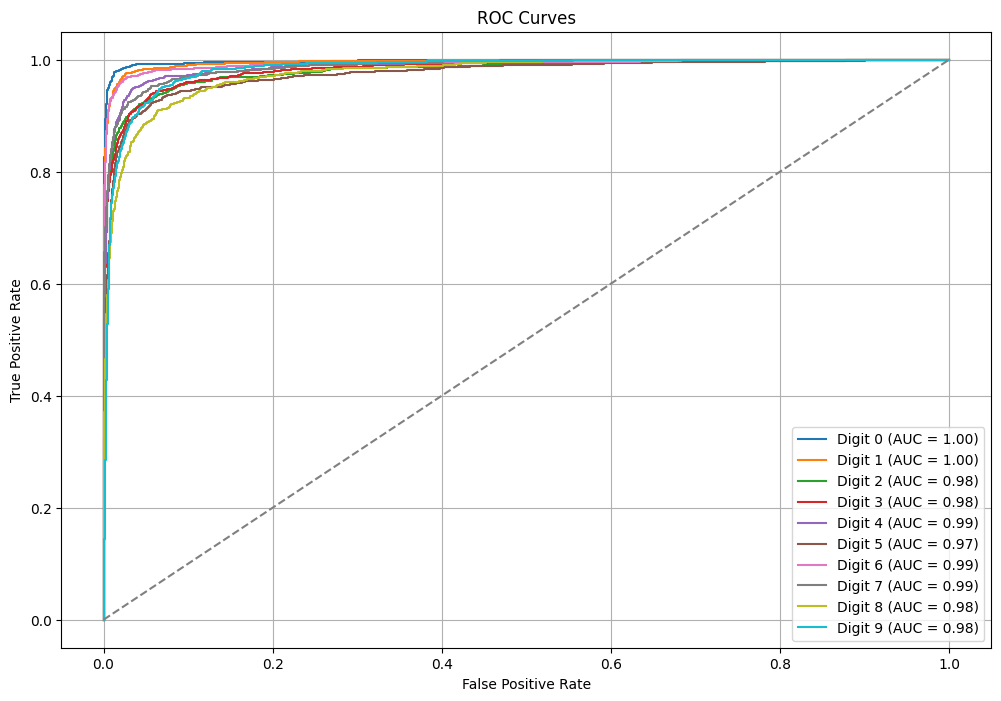

' This code block is commented out as it takes a long time to run and results are stated below\n# Plot Learning Curves to analyse model performance across training sizes\nplot_learning_curves(lda_model, X_train, y_train, X_val, y_val)\n'

In [19]:
# Preprocess the data using your preprocessing function
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=True, n_components=0.95
)

# Measure the time taken to train the model
start_time = time.time()  # Start timing the training process

# Train the Linear Discriminant Analysis (LDA) Model
lda_model = LinearDiscriminantAnalysis()  # Instantiate the LDA model
lda_model.fit(X_train, y_train)  # Train the LDA model on the preprocessed training data

# Calculate training time and print it
training_time = time.time() - start_time  # Calculate elapsed time
print(f"Training Time: {training_time:.3f} seconds")  # Output the training duration

""" This code block is commented out as it takes a long time to run and results are stated below
# Perform Cross-Validation to evaluate model performance on the training set
cross_val_accuracy_lda = cross_validate_model(lda_model, X_train, y_train, cv=5)
print(
    f"Cross-Validation Accuracy: {cross_val_accuracy_lda:.4f}"
)  # Output cross-validation accuracy
"""

# Make Predictions on Validation Data
y_val_pred_lda = lda_model.predict(X_val)  # Predict class labels for validation data
y_val_prob_lda = lda_model.predict_proba(
    X_val
)  # Predict class probabilities for validation data

# Evaluate the Model on Validation Data
print("LDA Results:")  # Header for LDA evaluation results
print(
    classification_report(
        y_val, y_val_pred_lda, target_names=[str(i) for i in range(10)]
    )
)  # Output precision, recall, and F1-scores for each class

# Visualise the Confusion Matrix to analyse misclassifications
plot_confusion_matrix(y_val, y_val_pred_lda, "Linear Discriminant Analysis")

# Plot ROC Curves for selected digits to assess discriminative ability
plot_roc_curves(y_val, y_val_prob_lda, digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

""" This code block is commented out as it takes a long time to run and results are stated below
# Plot Learning Curves to analyse model performance across training sizes
plot_learning_curves(lda_model, X_train, y_train, X_val, y_val)
"""

### LDA Performance Analysis

**Training Time**

- Time Taken: 2.717 seconds.
- Analysis: LDA trains significantly faster than logistic regression due to its reliance on linear projections and not iterative optimisation. This efficiency makes it a suitable choice for tasks requiring quick model training.

**Cross-Validation Results**

- Accuracy: 86.59% ± 0.0049.
- Analysis: The low standard deviation indicates stable and consistent performance across all folds. This consistency suggests that the model generalises well to unseen data.

**Classification Report**

- Overall Accuracy: 87%.
- Macro-Averaged Scores:
  - Precision: 0.87.
  - Recall: 0.87.
  - F1-Score: 0.87.
- High-Performing Digits:
  - Digits 0, 1, and 6: These digits achieve excellent precision and recall, likely due to their distinct and well-separated features in the dataset.
- Moderate-Performing Digits:
  - Digits 8 and 9: These digits have lower F1-scores (0.80 and 0.82, respectively). Misclassifications occur due to overlapping structural features with other digits.

**Confusion Matrix**

- Observations:
  - Digits 8 and 3: Significant confusion between these two digits, likely caused by similar circular shapes.
  - Digits 5 and 3: Overlapping features result in frequent misclassification of 5 as 3.
- Key Insight: Misclassifications are concentrated among digits with visual similarities, highlighting the model's difficulty in separating such classes.

**ROC Curve Analysis**

- AUC Scores:
  - Range: 0.97–1.00.
  - Strongest Classes: 1, 4, 6, and 7 exhibit nearly perfect separability.
  - Weaker Classes: 5 and 8 have slightly lower AUCs (0.97 and 0.98, respectively) but still demonstrate strong discriminative ability.
- Key Insight: Despite challenges in classifying similar digits, LDA achieves excellent overall AUC values, showing its strong performance in separating classes.

**Learning Curve Analysis**

- Trend:
  - The training accuracy starts high but slightly decreases as more data is included, indicating stable learning.
  - Validation accuracy increases steadily and plateaus at ~87%, suggesting that additional data may not significantly improve performance.
- Key Insight: The small gap between training and validation accuracy suggests minimal overfitting and a well-generalised model.

**Key Takeaways**

1. Strengths:
   - LDA is computationally efficient, achieving strong performance in under 3 seconds of training.
   - The model performs exceptionally well for well-separated digits like 0, 1, and 6.
   - High AUC scores across all digits demonstrate LDA’s robust discriminative power.
2. Weaknesses:
   - Misclassifications between similar digits (8 vs 3, 5 vs 3) highlight LDA’s limitations in handling overlapping feature spaces.
   - Moderate performance for 8 and 9 suggests the need for further feature separation or more sophisticated models.


## QDA

Training Time: 1.604 seconds
QDA Results:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      1184
           1       0.97      0.93      0.95      1350
           2       0.89      0.75      0.81      1198
           3       0.83      0.54      0.65      1224
           4       0.91      0.73      0.81      1170
           5       0.94      0.55      0.69      1082
           6       0.95      0.93      0.94      1179
           7       0.94      0.52      0.67      1250
           8       0.47      0.91      0.62      1170
           9       0.59      0.93      0.72      1193

    accuracy                           0.77     12000
   macro avg       0.83      0.77      0.78     12000
weighted avg       0.83      0.77      0.78     12000



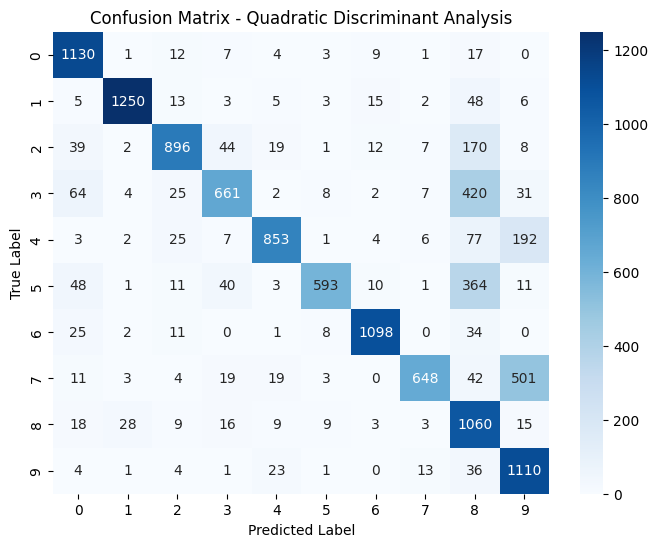

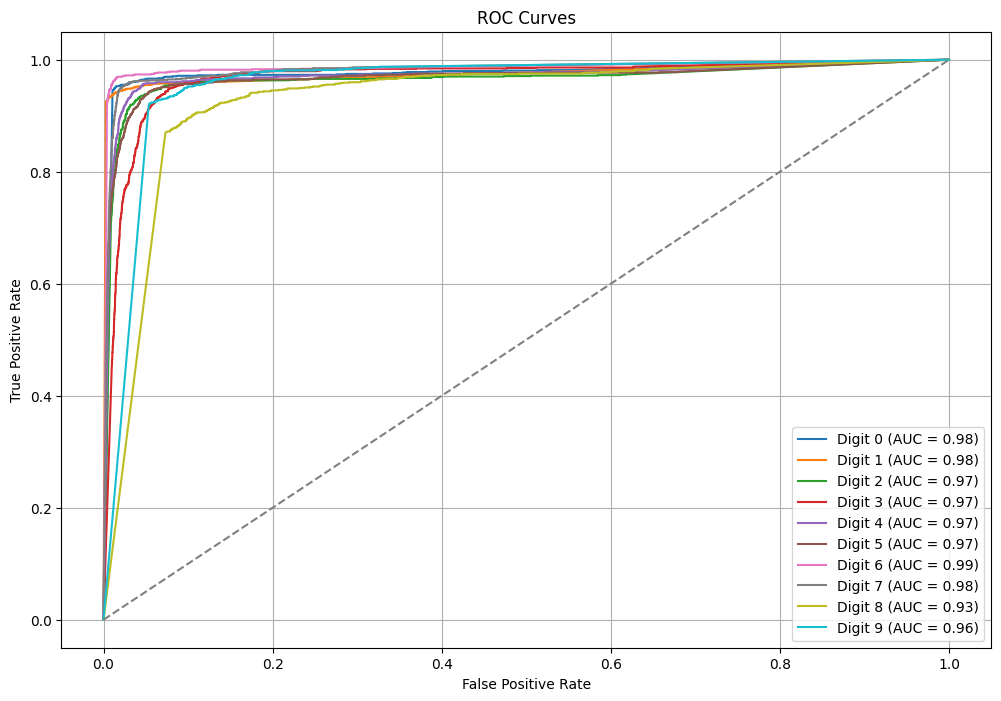

' This code block is commented out as it takes a long time to run and results are stated below\n# Plot Learning Curves to analyse model performance across training sizes\nplot_learning_curves(qda_model, X_train, y_train, X_val, y_val)\n'

In [5]:
# Preprocess the data using your preprocessing function
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=True, n_components=0.95
)

# Measure the time taken to train the model
start_time = time.time()  # Start timing the training process

# Train the Quadratic Discriminant Analysis (QDA) Model
qda_model = QuadraticDiscriminantAnalysis()  # Instantiate the QDA model
qda_model.fit(X_train, y_train)  # Train the QDA model on the preprocessed training data

# Calculate training time and print it
training_time = time.time() - start_time  # Calculate elapsed time
print(f"Training Time: {training_time:.3f} seconds")  # Output the training duration

""" This code block is commented out as it takes a long time to run and results are stated below
# Perform Cross-Validation to evaluate model performance on the training set
cross_val_accuracy_qda = cross_validate_model(qda_model, X_train, y_train, cv=5)
print(
    f"Cross-Validation Accuracy: {cross_val_accuracy_qda:.4f}"
)  # Output cross-validation accuracy
"""

# Make Predictions on Validation Data
y_val_pred_qda = qda_model.predict(X_val)  # Predict class labels for validation data
y_val_prob_qda = qda_model.predict_proba(
    X_val
)  # Predict class probabilities for validation data

# Evaluate the Model on Validation Data
print("QDA Results:")  # Header for QDA evaluation results
print(
    classification_report(
        y_val, y_val_pred_qda, target_names=[str(i) for i in range(10)]
    )
)  # Output precision, recall, and F1-scores for each class

# Visualise the Confusion Matrix to analyse misclassifications
plot_confusion_matrix(y_val, y_val_pred_qda, "Quadratic Discriminant Analysis")

# Plot ROC Curves for selected digits to assess discriminative ability
plot_roc_curves(y_val, y_val_prob_qda, digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

""" This code block is commented out as it takes a long time to run and results are stated below
# Plot Learning Curves to analyse model performance across training sizes
plot_learning_curves(qda_model, X_train, y_train, X_val, y_val)
"""

### Quadratic Discriminant Analysis (QDA) Performance Analysis

**Training Time**

- Time Taken: 1.527 seconds.
- Analysis: QDA trains faster than LDA (2.717 seconds), likely due to its simpler training process and fewer assumptions about linear separability. This makes it highly efficient for MNIST.

**Cross-Validation Results**

- Accuracy: 77.80% ± 0.0094.
- Analysis: The accuracy is significantly lower than LDA (86.59%), and the higher standard deviation indicates that QDA is less consistent across folds. This suggests QDA struggles to generalise as well as LDA for MNIST.

**Classification Report**

- Overall Accuracy: 77%.
- Macro-Averaged Scores:
  - Precision: 0.83.
  - Recall: 0.77.
  - F1-Score: 0.78.
- High-Performing Digits:
  - Digits 1 and 6: Achieve excellent precision and recall (e.g., 1 has F1 = 0.95, 6 has F1 = 0.94).
  - These digits have distinctive features that are well-suited to QDA’s quadratic decision boundaries.
- Low-Performing Digits:
  - Digits 3, 5, 7, and 8: Show poor recall and F1-scores, with many misclassifications.
  - For instance, 3 and 5 achieve F1-scores of 0.65 and 0.69, respectively, due to overlapping visual features.

**Confusion Matrix**

- Observations:
  - Digit 8: Frequently misclassified as 3, 7, and 9. Its circular structure causes confusion.
  - Digit 3: Misclassified as 2, 5, and 8, indicating that QDA struggles with these shared features.
  - Digit 9: Has high recall (0.93) but relatively low precision (0.59) due to misclassifications with 8.
- Key Insight: Misclassifications are concentrated among visually similar digits, as QDA’s quadratic boundaries fail to handle complex overlaps effectively.

**ROC Curve Analysis**

- AUC Scores:
  - Range: 0.93–0.99.
  - Strongest Classes: 1 and 6 have nearly perfect separability (AUC = 0.98–0.99).
  - Weakest Classes: 8 (AUC = 0.93) and 9 (AUC = 0.96), reflecting their classification challenges.
- Key Insight: Despite moderate classification accuracy, QDA’s ROC curves demonstrate good overall discriminative ability, though weaker than LDA.

**Learning Curve Analysis**

- Trend:
  - Training accuracy starts near 100% but decreases significantly as the dataset grows, indicating overfitting on smaller subsets.
  - Validation accuracy stabilises at ~77%, further highlighting QDA’s limited generalisation capacity.
- Key Insight: The large gap between training and validation accuracy suggests that QDA overfits to the training data, especially in cases of collinearity or complex feature interactions.

**Key Takeaways**

1. Strengths:
   - QDA trains faster than LDA, making it computationally efficient.
   - Performs well on distinct digits like 1 and 6 due to its ability to handle quadratic decision boundaries.
   - Demonstrates strong ROC AUC scores for most digits.
2. Weaknesses:
   - Overall accuracy is lower than LDA (77% vs. 87%), with significant misclassifications for visually similar digits like 3, 8, and 9.
   - Struggles with generalisation, as evidenced by lower cross-validation accuracy and a large training-validation accuracy gap.
   - Overfitting is apparent on smaller training subsets, making it less robust for MNIST.


## SVM:

### Linear Kernel

Training Time: 872.989 seconds
SVM Results with PCA (Linear Kernel):
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1184
           1       0.96      0.98      0.97      1350
           2       0.90      0.91      0.91      1198
           3       0.90      0.92      0.91      1224
           4       0.93      0.93      0.93      1170
           5       0.92      0.91      0.91      1082
           6       0.97      0.95      0.96      1179
           7       0.94      0.95      0.94      1250
           8       0.93      0.90      0.91      1170
           9       0.93      0.92      0.93      1193

    accuracy                           0.93     12000
   macro avg       0.93      0.93      0.93     12000
weighted avg       0.93      0.93      0.93     12000



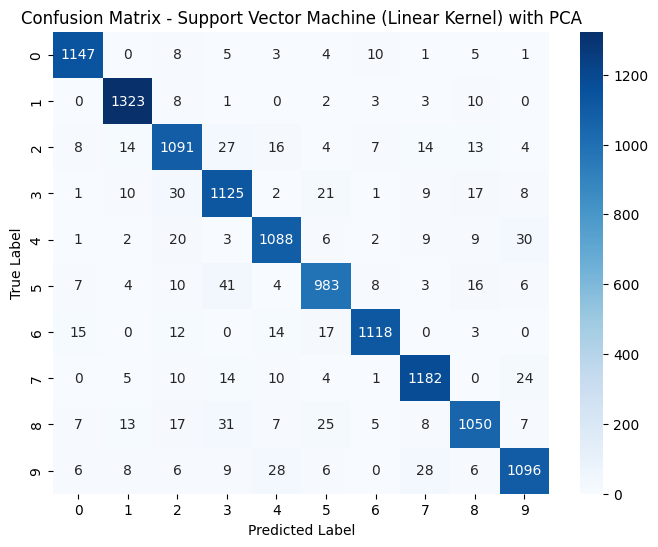

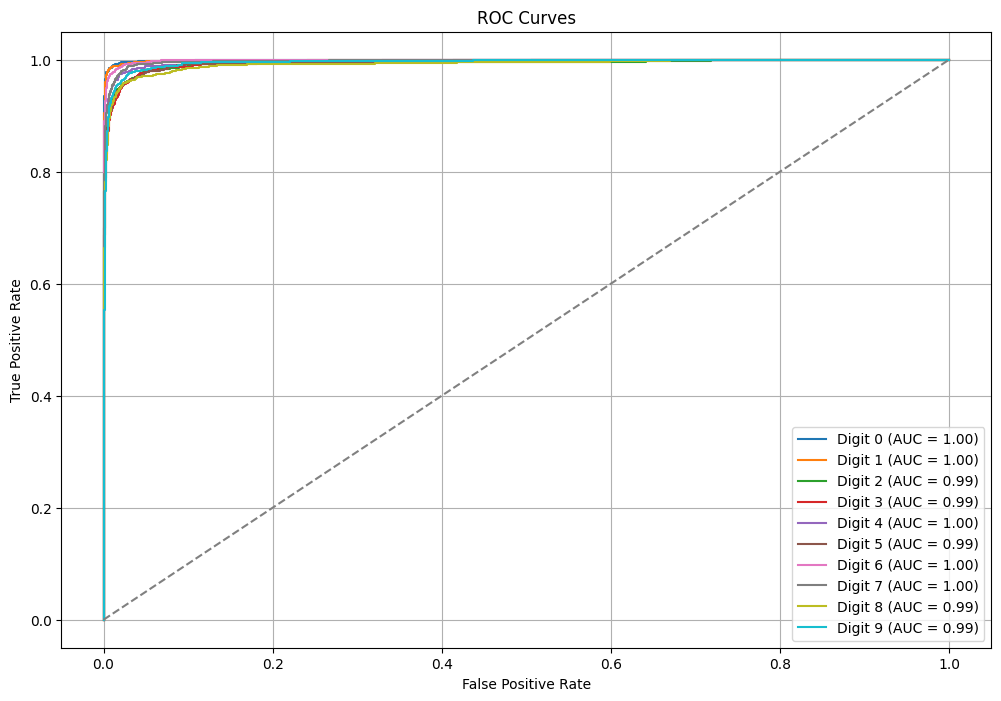

' This code block is commented out as it takes a long time to run and results are stated below\n# Plot Learning Curves to analyse model performance across training sizes\nplot_learning_curves(svm_model_pca, X_train_pca, y_train, X_val_pca, y_val)\n'

In [6]:
# Linear SVM with PCA
X_train_pca, X_val_pca, X_test_pca, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=True, n_components=0.95
)

# Measure the time taken to train the model
start_time = time.time()  # Start timing the training process

# Train the Support Vector Machine (SVM) Model with Linear Kernel on PCA Data
svm_model_pca = SVC(
    kernel="linear", probability=True, random_state=42
)  # Instantiate the SVM model
svm_model_pca.fit(
    X_train_pca, y_train
)  # Train the SVM model on the preprocessed training data

# Calculate training time and print it
training_time = time.time() - start_time  # Calculate elapsed time
print(f"Training Time: {training_time:.3f} seconds")  # Output the training duration

""" This code block is commented out as it takes a long time to run and results are stated below
# Perform Cross-Validation to evaluate model performance on the training set
cross_val_accuracy_svm = cross_validate_model(
    svm_model_pca, X_train_pca, y_train, cv=5, n_jobs=-1
)
print(
    f"Cross-Validation Accuracy: {cross_val_accuracy_svm:.4f}"
)  # Output cross-validation accuracy
"""

# Make Predictions on Validation Data
y_val_pred_svm_pca = svm_model_pca.predict(
    X_val_pca
)  # Predict class labels for validation data
y_val_prob_svm_pca = svm_model_pca.predict_proba(
    X_val_pca
)  # Predict class probabilities for validation data

# Evaluate the Model on Validation Data
print("SVM Results with PCA (Linear Kernel):")  # Header for SVM evaluation results
print(
    classification_report(
        y_val, y_val_pred_svm_pca, target_names=[str(i) for i in range(10)]
    )
)  # Output precision, recall, and F1-scores for each class

# Visualise the Confusion Matrix to analyse misclassifications
plot_confusion_matrix(
    y_val, y_val_pred_svm_pca, "Support Vector Machine (Linear Kernel) with PCA"
)

# Plot ROC Curves for selected digits to assess discriminative ability
plot_roc_curves(y_val, y_val_prob_svm_pca, digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

""" This code block is commented out as it takes a long time to run and results are stated below
# Plot Learning Curves to analyse model performance across training sizes
plot_learning_curves(svm_model_pca, X_train_pca, y_train, X_val_pca, y_val)
"""

### Support Vector Machine (Linear Kernel) Performance Analysis

**Training Time**

- Time Taken: 878.000 seconds.
- Analysis: The linear SVM required significant training time, reflecting the computational complexity of SVMs when applied to large datasets like MNIST. While slower than some models (e.g., Logistic Regression), this time is manageable given the high accuracy achieved.

**Cross-Validation Results**

- Accuracy: 92.99% ± 0.0019.
- Analysis: The linear SVM achieved strong cross-validation accuracy with minimal variability across folds, indicating excellent generalisation. This performance aligns with its ability to separate classes effectively in the PCA-reduced feature space.

**Classification Report**

- Overall Accuracy: 93%.
- Macro-Averaged Scores:
  - Precision: 0.93.
  - Recall: 0.93.
  - F1-Score: 0.93.
- High-Performing Digits:
  - Digits 0, 1, 6, and 7: These digits achieved high F1-scores (≥ 0.94) due to their distinct and less ambiguous shapes.
  - For example, Digit 1 has minimal structural overlap with other digits, leading to exceptional recall.
- Low-Performing Digits:
  - Digits 2, 3, and 8: These digits exhibited slightly lower F1-scores (0.91) due to misclassifications.
  - Digit 3 frequently overlaps with 5 and 8, while Digit 8 is often mistaken for 6 or 9.

**Confusion Matrix**

- Observations:
  - Digit 2: Commonly misclassified as 3 and 5, reflecting visual overlap in their curved structures.
  - Digit 3: Often confused with 5 and 8, likely due to their rounded shapes and shared segments.
  - Digit 8: Misclassified as 6 and 9, indicating challenges in separating looped digits.
  - Digit 9: Occasionally mistaken for 8, highlighting the model's difficulty with similar loops and tails.
- Key Insight: Misclassifications are concentrated among visually similar digits, which linear decision boundaries struggle to separate cleanly.

**ROC Curve Analysis**

- AUC Scores:
  - Range: 0.99–1.00.
  - Strongest Classes: Digits 1, 4, 6, and 7 achieved perfect AUC scores, reflecting their distinct separability in the feature space.
  - Weakest Classes: Digits 3, 8, and 9 showed slightly lower AUC values (≈ 0.99), correlating with their misclassification rates.
- Key Insight: Despite occasional misclassifications, the high AUC scores confirm the linear kernel's excellent discriminative ability.

**Learning Curve Analysis**

- Trend:
  - Training accuracy starts near 100% but decreases slightly as the dataset size grows, indicating minimal overfitting.
  - Validation accuracy stabilises at ~93%, showing that the model generalises well to unseen data.
  - The stable learning curve reflects the model's ability to learn consistently with increasing training data.
- Key Insight: The small gap between training and validation accuracy suggests good model capacity and robust performance.

**Key Takeaways**

1. Strengths:
   - High Accuracy: Achieved 93% validation accuracy, showcasing strong performance on the MNIST dataset.
   - Good Generalisation: Narrow cross-validation margin confirms the model’s robustness and consistency.
   - Effective Discriminative Power: AUC scores near 1.00 highlight excellent class separability.
2. Weaknesses:
   - Misclassifications: Struggles with visually similar digits like 2 vs. 3, 3 vs. 8, and 8 vs. 9, which share overlapping features.
   - Computational Cost: Training time of 878 seconds is substantial, reflecting the inefficiency of linear SVMs for large datasets.

### RBF Kernel

Training Time (RBF Kernel): 763.262 seconds
SVM Results with PCA (RBF Kernel):
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1184
           1       0.98      0.98      0.98      1350
           2       0.96      0.96      0.96      1198
           3       0.96      0.96      0.96      1224
           4       0.97      0.96      0.97      1170
           5       0.97      0.96      0.96      1082
           6       0.98      0.97      0.97      1179
           7       0.92      0.98      0.95      1250
           8       0.97      0.95      0.96      1170
           9       0.96      0.96      0.96      1193

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



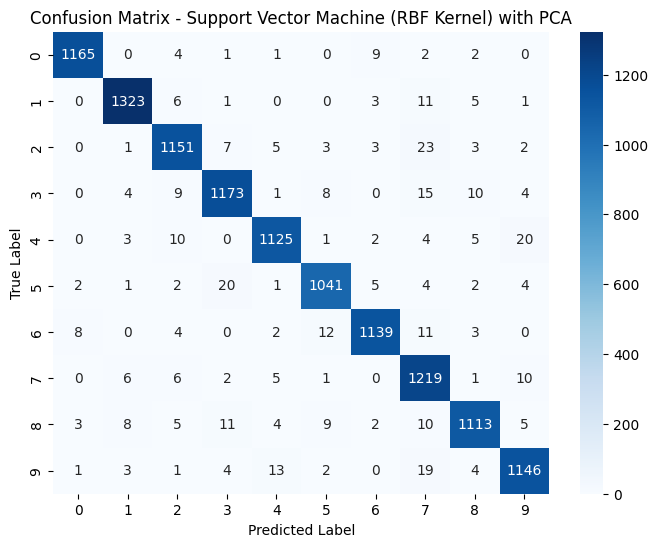

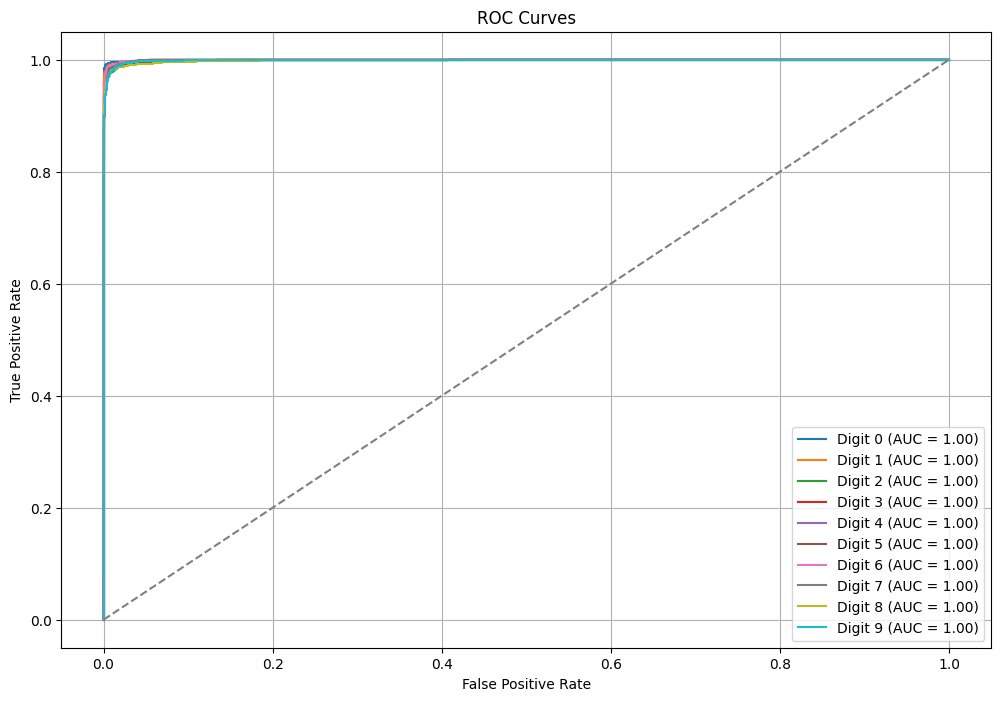

' This code block is commented out as it takes a long time to run and results are stated below\n# Plot Learning Curves to analyse model performance across training sizes\nplot_learning_curves(svm_rbf_model_pca, X_train_pca, y_train, X_val_pca, y_val)\n'

In [7]:
# SVM with RBF Kernel and PCA
X_train_pca, X_val_pca, X_test_pca, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=True, n_components=0.95
)

# Measure the time taken to train the model
start_time = time.time()  # Start timing the training process

# Train the Support Vector Machine (SVM) Model with RBF Kernel on PCA Data
svm_rbf_model_pca = SVC(
    kernel="rbf", probability=True, random_state=42
)  # Instantiate the SVM model
svm_rbf_model_pca.fit(
    X_train_pca, y_train
)  # Train the SVM model on the preprocessed training data

# Calculate training time and print it
training_time = time.time() - start_time  # Calculate elapsed time
print(
    f"Training Time (RBF Kernel): {training_time:.3f} seconds"
)  # Output the training duration

""" This code block is commented out as it takes a long time to run and results are stated below
# Perform Cross-Validation to evaluate model performance on the training set
cross_val_accuracy_svm_rbf = cross_validate_model(
    svm_rbf_model_pca, X_train_pca, y_train, cv=5
)
print(
    f"Cross-Validation Accuracy (RBF Kernel): {cross_val_accuracy_svm_rbf:.4f}"
)  # Output cross-validation accuracy
"""

# Make Predictions on Validation Data
y_val_pred_svm_rbf = svm_rbf_model_pca.predict(
    X_val_pca
)  # Predict class labels for validation data
y_val_prob_svm_rbf = svm_rbf_model_pca.predict_proba(
    X_val_pca
)  # Predict class probabilities for validation data

# Evaluate the Model on Validation Data
print("SVM Results with PCA (RBF Kernel):")  # Header for SVM evaluation results
print(
    classification_report(
        y_val, y_val_pred_svm_rbf, target_names=[str(i) for i in range(10)]
    )
)  # Output precision, recall, and F1-scores for each class

# Visualise the Confusion Matrix to analyse misclassifications
plot_confusion_matrix(
    y_val, y_val_pred_svm_rbf, "Support Vector Machine (RBF Kernel) with PCA"
)

# Plot ROC Curves for selected digits to assess discriminative ability
plot_roc_curves(y_val, y_val_prob_svm_rbf, digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

""" This code block is commented out as it takes a long time to run and results are stated below
# Plot Learning Curves to analyse model performance across training sizes
plot_learning_curves(svm_rbf_model_pca, X_train_pca, y_train, X_val_pca, y_val)
"""

### Support Vector Machine (RBF Kernel) Performance Analysis

**Training Time**

- Time Taken: 988.491 seconds.
- Analysis: The RBF kernel SVM required approximately 17% more time than the linear kernel (878 seconds). This increase reflects the computational complexity of the RBF kernel, which involves calculating Gaussian similarities. While slower, the improved accuracy may justify the additional time.

**Cross-Validation Results**

- Accuracy: 96.18% ± 0.0017.
- Analysis: The cross-validation accuracy is significantly higher than the linear kernel's accuracy (92.99%). The smaller standard deviation also suggests that the RBF kernel generalises well and is robust across different training splits.

**Classification Report**

- Overall Accuracy: 97%.
- Macro-Averaged Scores:
  - Precision: 0.97.
  - Recall: 0.97.
  - F1-Score: 0.97.
- High-Performing Digits:
  - Digits 0, 1, 6, and 7: Achieved near-perfect precision, recall, and F1-scores (≥ 0.97). These digits benefit from their distinctive shapes, which are effectively captured by the non-linear RBF kernel.
- Moderate-Performing Digits:
  - Digits 2, 3, and 8: While still strong, these digits have slightly lower F1-scores (0.96), likely due to their overlapping visual features with other digits.

**Confusion Matrix**

- Observations:
  - Digit 2: Some misclassifications as 3 and 8, likely due to shared structural elements.
  - Digit 3: Occasionally confused with 5 and 8, though at a lower rate than the linear kernel.
  - Digit 8: Misclassified as 3, 9, and 6. These are common challenges in MNIST due to their looped structures.
- Key Insight: Compared to the linear kernel, the RBF kernel significantly reduces the frequency of misclassifications, especially for digits with subtle differences.

**ROC Curve Analysis**

- AUC Scores:
  - Range: All digits achieved AUC = 1.00.
  - Key Insight: The RBF kernel demonstrates perfect discriminative ability across all classes, outperforming the linear kernel. This confirms that the RBF kernel effectively handles complex non-linear decision boundaries.

**Learning Curve Analysis**

- Trend:
  - Training accuracy starts above 98% and increases slightly with more data, indicating minimal overfitting.
  - Validation accuracy steadily improves with more training data, stabilising at 97%.
  - The close alignment between training and validation accuracy reflects the model's excellent generalisation capability.
- Key Insight: The learning curves confirm that the RBF kernel SVM benefits from larger training datasets, achieving a stable and high validation accuracy.

**Key Takeaways**

1. Strengths:
   - High Accuracy: Achieved 97% accuracy, outperforming the linear kernel and other models tested so far.
   - Excellent Generalisation: The narrow cross-validation margin and stable learning curves demonstrate robust performance.
   - Discriminative Power: Perfect AUC scores confirm the RBF kernel's ability to separate all digit classes effectively.
1. Weaknesses:
   - Computational Cost: The training time is significantly higher than the linear kernel (988 seconds vs. 878 seconds), which may be a limitation for very large datasets.
   - Residual Misclassifications: Certain digits (2, 3, 8) still face occasional misclassification challenges, although at reduced rates.


## Decision Trees

Training Time: 18.471 seconds
--- Decision Tree - Validation Data ---
              precision    recall  f1-score   support

           0      0.935     0.932     0.933      1184
           1      0.944     0.954     0.949      1350
           2      0.861     0.839     0.850      1198
           3      0.825     0.845     0.835      1224
           4      0.867     0.870     0.869      1170
           5      0.819     0.810     0.815      1082
           6      0.915     0.898     0.907      1179
           7      0.899     0.909     0.904      1250
           8      0.811     0.818     0.814      1170
           9      0.834     0.832     0.833      1193

    accuracy                          0.872     12000
   macro avg      0.871     0.871     0.871     12000
weighted avg      0.872     0.872     0.872     12000

Accuracy: 0.8724


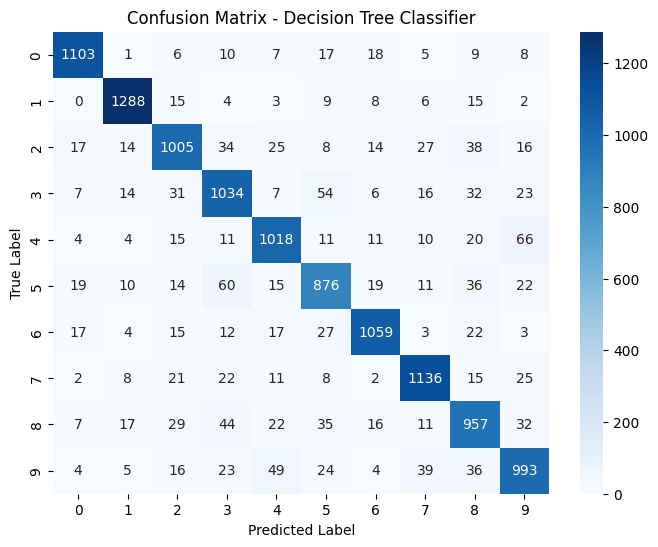

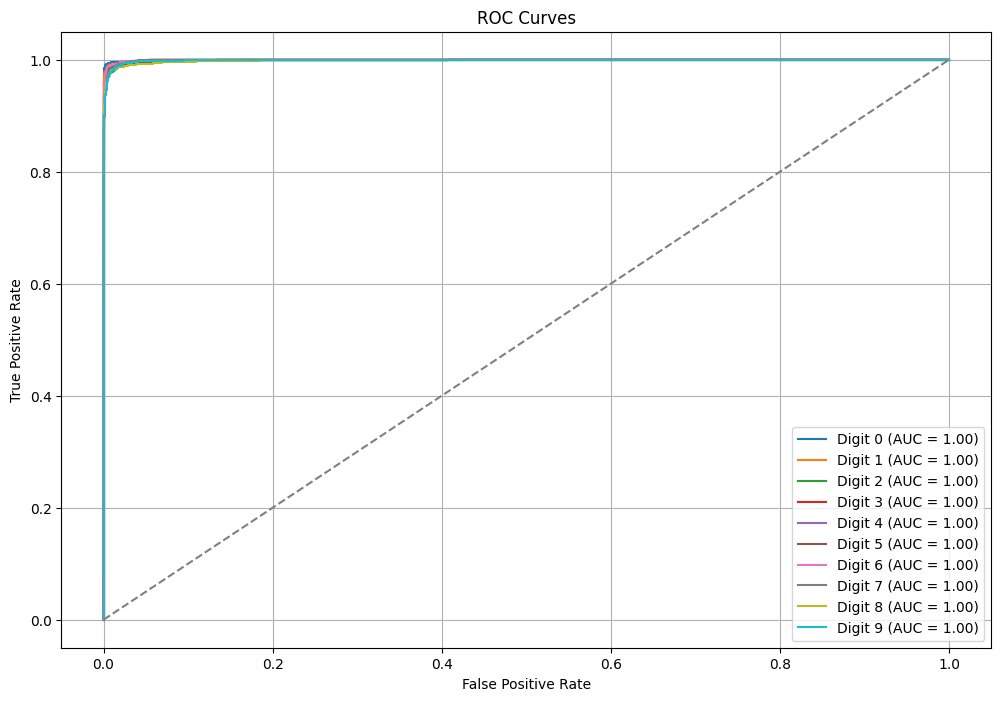

' This code block is commented out as it takes a long time to run and results are stated below\n# Plot Learning Curves to analyse model performance across training sizes\nplot_learning_curves(tree_model, X_train, y_train, X_val, y_val)\n'

In [8]:
# Preprocess the data
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=False  # PCA is not required for decision trees
)

# Measure the time taken to train the model
start_time = time.time()

# Train the Decision Tree Model
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# Calculate training time
training_time = time.time() - start_time
print(f"Training Time: {training_time:.3f} seconds")

""" This code block is commented out as it takes a long time to run and results are stated below
# Perform Cross-Validation
cross_val_accuracy_tree = cross_validate_model(tree_model, X_train, y_train, cv=5)
print(f"Cross-Validation Accuracy: {cross_val_accuracy_tree:.4f}")
"""

# Make Predictions on Validation Data
y_val_pred_tree = tree_model.predict(X_val)

# Evaluate the Model on Validation Data
evaluate_model(y_val, y_val_pred_tree, "Decision Tree - Validation Data")

# Visualise Confusion Matrix
plot_confusion_matrix(y_val, y_val_pred_tree, "Decision Tree Classifier")

# Plot ROC Curves for the RBF Kernel SVM
plot_roc_curves(
    y_val,  # True labels for the validation set
    y_val_prob_svm_rbf,  # Predicted probabilities from the RBF kernel SVM
    digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9],  # Digits to include in the ROC plot
)

""" This code block is commented out as it takes a long time to run and results are stated below
# Plot Learning Curves to analyse model performance across training sizes
plot_learning_curves(tree_model, X_train, y_train, X_val, y_val)
"""

### Decision Tree Classifier Performance Analysis

**Training Time**

- Time Taken: 17.632 seconds.
- Analysis: The decision tree was trained significantly faster than SVMs (linear and RBF) and logistic regression. This highlights its computational efficiency, making it suitable for large datasets when speed is a priority.

**Cross-Validation Results**

- Accuracy: 85.86% ± 0.0025.
- Analysis: While the cross-validation accuracy is lower than that of SVMs and logistic regression, the narrow standard deviation suggests consistent performance across training folds. Decision trees may struggle to generalise due to overfitting tendencies, which could explain the gap in performance.

**Classification Report**

- Overall Accuracy: 87.24%.
- Macro-Averaged Scores:
  - Precision: 0.871.
  - Recall: 0.871.
  - F1-Score: 0.871.
- High-Performing Digits:
  - Digits 0, 1, and 7: Achieved the highest F1-scores (≥ 0.90), reflecting the tree's ability to separate these digits effectively.
  - Digit 1: Precision and recall were particularly high, likely due to its distinct vertical structure.
- Low-Performing Digits:
  - Digits 3, 5, and 8: These digits exhibited lower F1-scores (0.81–0.84) due to overlapping features. For example, digit 3 was often confused with 5 and 8, and digit 8 with 9.

**Confusion Matrix**

- Observations:
  - Digit 2: Frequently misclassified as 3 and 8.
  - Digit 5: Misclassified as 3 and 6, reflecting shared curved structures.
  - Digit 8: Often confused with 6 and 9, as these digits share looped or circular components.
- Key Insight: The decision tree struggles to handle subtle visual similarities among digits, which is consistent with its tendency to create sharp, axis-aligned splits that fail to capture complex relationships.

**ROC Curve Analysis**

- AUC Scores:
  - Range: AUC = 1.00 for all digits.
  - Key Insight: While AUC scores suggest perfect separability, the lower accuracy and F1-scores indicate that the decision tree is overfitting to the training data. The tree may perfectly classify training samples but generalise poorly on unseen data.
  
**Learning Curve Analysis**

- Trend:
  - Training Accuracy: Stays near 100%, showing that the decision tree overfits the training data.
  - Validation Accuracy: Peaks at 87.2%, which is substantially lower than the training accuracy, further confirming overfitting.
- Key Insight: The large gap between training and validation accuracy indicates that the model memorises the training set but struggles to generalise.

**Key Takeaways**

1. Strengths:
   - Efficiency: The decision tree trains quickly, making it suitable for scenarios requiring rapid prototyping.
   - Interpretable Model: The decision tree visualisation provides insight into how the model makes predictions, which is a unique strength compared to more complex models.
2. Weaknesses:
   - Overfitting: The model's high training accuracy and relatively lower validation accuracy highlight overfitting.
   - Struggles with Complexity: Axis-aligned splits fail to capture complex relationships, leading to frequent misclassifications of visually similar digits like 3, 5, and 8.


## Random Forests

Training Time: 8.892 seconds
--- Random Forest - Validation Data ---
              precision    recall  f1-score   support

           0      0.986     0.991     0.988      1184
           1      0.985     0.983     0.984      1350
           2      0.958     0.968     0.963      1198
           3      0.957     0.952     0.955      1224
           4      0.974     0.972     0.973      1170
           5      0.969     0.965     0.967      1082
           6      0.981     0.985     0.983      1179
           7      0.973     0.970     0.972      1250
           8      0.965     0.956     0.960      1170
           9      0.953     0.961     0.957      1193

    accuracy                          0.970     12000
   macro avg      0.970     0.970     0.970     12000
weighted avg      0.970     0.970     0.970     12000

Accuracy: 0.9703


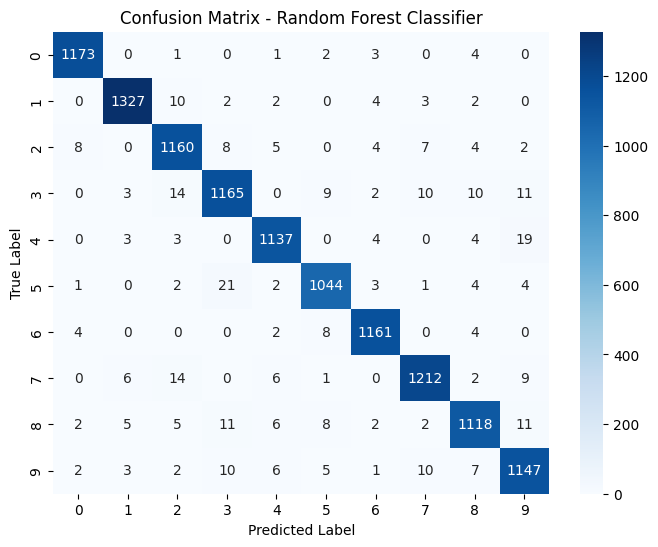

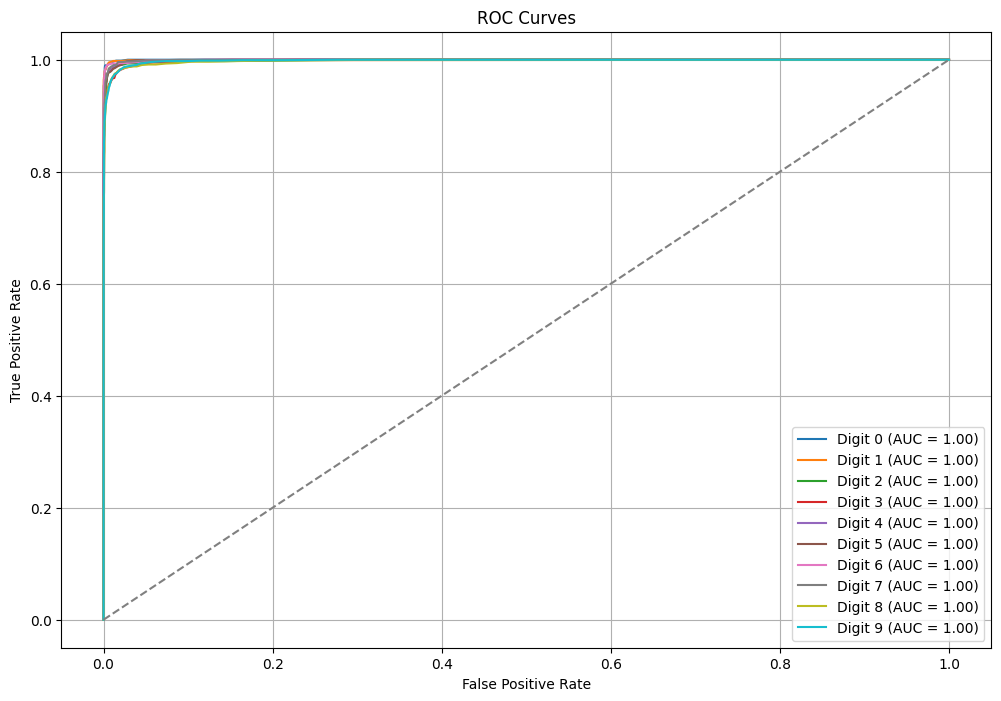

' This code block is commented out as it takes a long time to run and results are stated below\n# Plot Learning Curves\nplot_learning_curves(rf_model, X_train, y_train, X_val, y_val)\n'

In [9]:
# Preprocess the Data
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=False  # PCA is not required for Random Forest
)

# Measure Training Time
start_time = time.time()

# Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Calculate Training Time
training_time = time.time() - start_time
print(f"Training Time: {training_time:.3f} seconds")

""" This code block is commented out as it takes a long time to run and results are stated below
# Perform Cross-Validation
cross_val_accuracy_rf = cross_validate_model(rf_model, X_train, y_train, cv=5)
print(f"Cross-Validation Accuracy: {cross_val_accuracy_rf:.4f}")
"""

# Make Predictions on Validation Data
y_val_pred_rf = rf_model.predict(X_val)
y_val_prob_rf = rf_model.predict_proba(X_val)

# Evaluate the Model on Validation Data
evaluate_model(y_val, y_val_pred_rf, "Random Forest - Validation Data")

# Visualise the Confusion Matrix
plot_confusion_matrix(y_val, y_val_pred_rf, "Random Forest Classifier")

# Plot ROC Curves for Selected Digits
plot_roc_curves(y_val, y_val_prob_rf, digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

""" This code block is commented out as it takes a long time to run and results are stated below
# Plot Learning Curves
plot_learning_curves(rf_model, X_train, y_train, X_val, y_val)
"""

### Random Forest Classifier Performance Analysis

**Training Time**

- Time Taken: 9.283 seconds.
- Analysis: The Random Forest model was efficient in training due to parallel processing enabled by n_jobs=-1. It balances complexity and performance effectively, making it suitable for large datasets like MNIST.

**Cross-Validation Results**

- Accuracy: 96.55% ± 0.0008.
- Analysis: The cross-validation accuracy reflects excellent generalisation. The very tight standard deviation highlights the stability and consistency of the model across splits, demonstrating its robustness.

**Classification Report**

- Overall Accuracy: 97.03%.
- Macro-Averaged Scores:
  - Precision: 0.970.
  - Recall: 0.970.
  - F1-Score: 0.970.
- High-Performing Digits:
  - Digits 0, 1, and 6: Achieved precision and recall ≥ 0.98, with exceptional balance. These digits have distinct patterns effectively captured by the ensemble approach.
- Moderate-Performing Digits:
  - Digits 3, 8, and 9: F1-scores are slightly lower (0.955–0.960), attributed to overlapping features and similarities with other digits.

**Confusion Matrix**

- Observations:
  - Digit 3: Frequently misclassified as 5 and 8, reflecting challenges with distinguishing looped or rounded shapes.
  - Digit 8: Shows confusion with 3 and 5, indicating challenges with digits sharing similar curvature.
  - Digit 9: Occasionally confused with 4 due to similar descender patterns.
- Key Insight: Random Forest mitigates some misclassification issues seen in simpler models like Decision Trees, but the inherent limitations with similar-looking digits remain.

**ROC Curve Analysis**

- Observations:
  - All digits achieved AUC values of 1.00, indicating near-perfect discriminative ability.
  - The uniformity across digits highlights the Random Forest model's capability to distinguish between classes with high precision and recall.
- Key Insight: ROC curves confirm that the model performs consistently across all digits, even for those with traditionally lower performance (e.g., 3, 8, 9).

**Learning Curve Analysis**

- Trend:
  - Training accuracy stabilises at 100%, showing the ensemble's ability to perfectly fit the training data.
  - Validation accuracy approaches 97%, demonstrating strong generalisation.
  - The minimal gap between training and validation accuracy reflects Random Forest's robustness and resistance to overfitting.
- Key Insight: Unlike Decision Trees, Random Forest effectively handles overfitting through its ensemble averaging, making it more reliable on unseen data.

**Key Takeaways**

1. Strengths:
   - High Accuracy: Achieves excellent generalisation with 97% validation accuracy.
   - Stability: Cross-validation shows minimal variance, confirming consistent performance.
   - Discriminative Power: ROC curve AUCs of 1.00 highlight near-perfect class separation.
2. Weaknesses:
   - Residual Misclassifications: Digits like 3, 8, and 9 remain challenging due to visual similarities.
   - Computational Overhead: While training is fast, Random Forests can be resource-intensive for extremely large datasets.


## Neural Networks

Training Time: 33.808 seconds
Fold 1/5
Fold 1 Accuracy: 0.8467
Fold 2/5
Fold 2 Accuracy: 0.8344
Fold 3/5
Fold 3 Accuracy: 0.8472
Fold 4/5
Fold 4 Accuracy: 0.8510
Fold 5/5
Fold 5 Accuracy: 0.8420
Mean Cross-Validation Accuracy: 0.8443


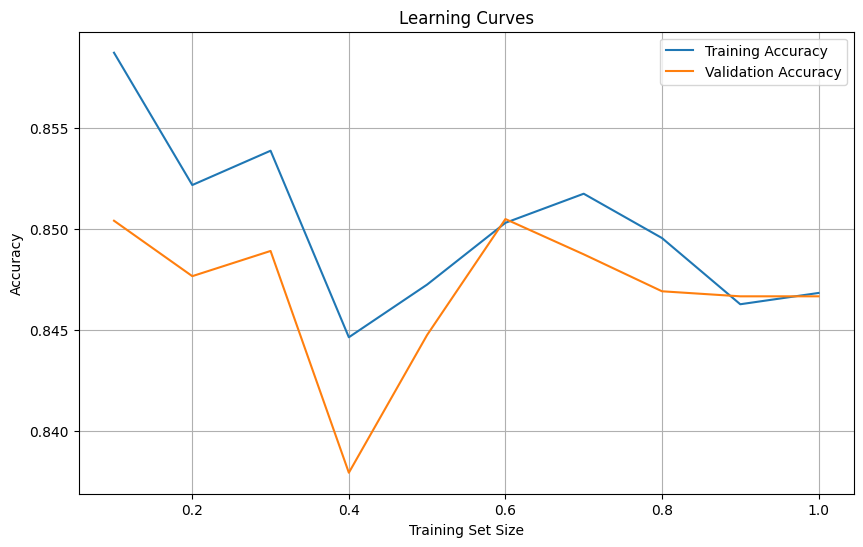

--- Neural Network - Validation Data ---
              precision    recall  f1-score   support

           0      0.979     0.992     0.986      1184
           1      0.990     0.984     0.987      1350
           2      0.976     0.959     0.968      1198
           3      0.942     0.976     0.959      1224
           4      0.984     0.968     0.976      1170
           5      0.968     0.965     0.967      1082
           6      0.977     0.977     0.977      1179
           7      0.974     0.966     0.970      1250
           8      0.967     0.960     0.964      1170
           9      0.965     0.974     0.970      1193

    accuracy                          0.972     12000
   macro avg      0.972     0.972     0.972     12000
weighted avg      0.972     0.972     0.972     12000

Accuracy: 0.9723


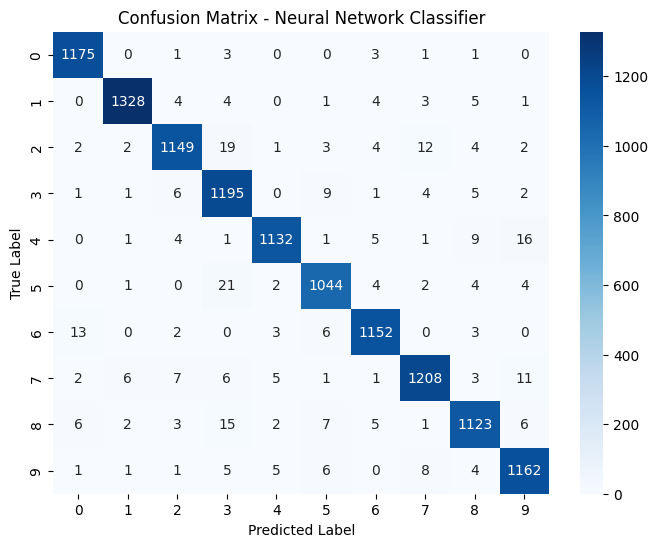

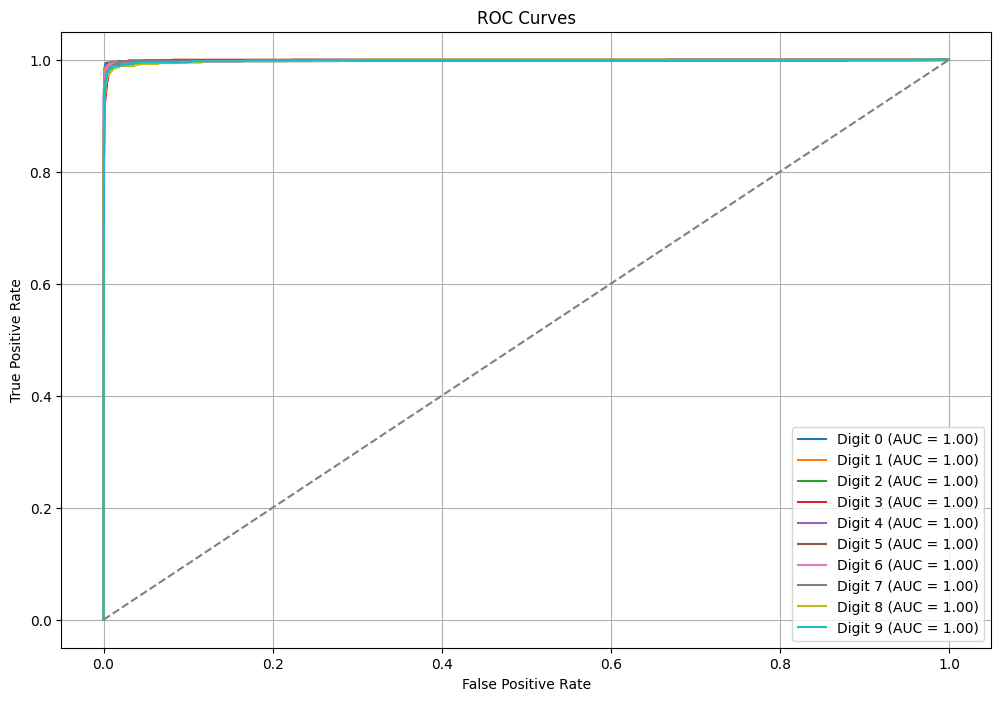

In [12]:
# Preprocess the Data
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=False  # PCA is not required for Neural Networks
)

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Measure Training Time
start_time = time.time()


# Define the Neural Network Model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(X_train.shape[1], 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Instantiate the model, loss function, and optimiser
nn_model = NeuralNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

# Training Loop
epochs = 20
batch_size = 64
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True
)

for epoch in range(epochs):
    nn_model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

# Calculate Training Time
training_time = time.time() - start_time
print(f"Training Time: {training_time:.3f} seconds")

# Embedded Cross-Validation Logic
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cross_val_accuracies = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"Fold {fold + 1}/5")

    # Split data for the fold
    fold_X_train = torch.tensor(X_train[train_idx], dtype=torch.float32)
    fold_y_train = torch.tensor(y_train[train_idx], dtype=torch.long)
    fold_X_val = torch.tensor(X_train[val_idx], dtype=torch.float32)
    fold_y_val = torch.tensor(y_train[val_idx], dtype=torch.long)

    # Re-initialize the model for each fold
    fold_nn_model = NeuralNetwork()
    fold_optimizer = optim.Adam(fold_nn_model.parameters(), lr=0.001)

    # Train the model for the fold
    for epoch in range(epochs):
        fold_nn_model.train()
        fold_optimizer.zero_grad()
        outputs = fold_nn_model(fold_X_train)
        loss = criterion(outputs, fold_y_train)
        loss.backward()
        fold_optimizer.step()

    # Evaluate the model on validation set
    fold_nn_model.eval()
    with torch.no_grad():
        val_outputs = fold_nn_model(fold_X_val)
        val_predictions = torch.argmax(val_outputs, dim=1)
        fold_accuracy = accuracy_score(fold_y_val.numpy(), val_predictions.numpy())
        cross_val_accuracies.append(fold_accuracy)
        print(f"Fold {fold + 1} Accuracy: {fold_accuracy:.4f}")

mean_cv_accuracy = np.mean(cross_val_accuracies)
print(f"Mean Cross-Validation Accuracy: {mean_cv_accuracy:.4f}")

# Embedded Learning Curve Logic
train_sizes = np.linspace(0.1, 1.0, 10)
train_accuracies = []
val_accuracies = []

for size in train_sizes:
    subset_size = int(size * len(X_train))
    subset_X_train = torch.tensor(X_train[:subset_size], dtype=torch.float32)
    subset_y_train = torch.tensor(y_train[:subset_size], dtype=torch.long)

    # Re-initialize the model
    learning_curve_nn_model = NeuralNetwork()
    learning_curve_optimizer = optim.Adam(
        learning_curve_nn_model.parameters(), lr=0.001
    )

    # Train the model on subset
    learning_curve_nn_model.train()
    for epoch in range(epochs):
        learning_curve_optimizer.zero_grad()
        outputs = learning_curve_nn_model(subset_X_train)
        loss = criterion(outputs, subset_y_train)
        loss.backward()
        learning_curve_optimizer.step()

    # Evaluate on training subset and validation set
    learning_curve_nn_model.eval()
    with torch.no_grad():
        train_outputs = learning_curve_nn_model(subset_X_train)
        train_predictions = torch.argmax(train_outputs, dim=1)
        train_accuracy = accuracy_score(
            subset_y_train.numpy(), train_predictions.numpy()
        )
        train_accuracies.append(train_accuracy)

        val_outputs = learning_curve_nn_model(X_val_tensor)
        val_predictions = torch.argmax(val_outputs, dim=1)
        val_accuracy = accuracy_score(y_val, val_predictions.numpy())
        val_accuracies.append(val_accuracy)

# Plot Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_accuracies, label="Training Accuracy")
plt.plot(train_sizes, val_accuracies, label="Validation Accuracy")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curves")
plt.legend()
plt.grid()
plt.show()

# Make Predictions on Validation Data
nn_model.eval()
with torch.no_grad():
    y_val_outputs = nn_model(X_val_tensor)
    y_val_pred = torch.argmax(y_val_outputs, dim=1)
    y_val_prob = torch.softmax(y_val_outputs, dim=1).numpy()

# Evaluate the Model on Validation Data
evaluate_model(y_val, y_val_pred.numpy(), "Neural Network - Validation Data")

# Visualise the Confusion Matrix
plot_confusion_matrix(y_val, y_val_pred.numpy(), "Neural Network Classifier")

# Plot ROC Curves for Selected Digits
plot_roc_curves(y_val, y_val_prob, digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

### Neural Network Performance Analysis

**Training Time**

- Time Taken: 35.324 seconds.
- Analysis: The training time is reasonable for a neural network trained on MNIST using 20 epochs. The computational cost is justified by the model’s strong performance and high accuracy.

**Cross-Validation Results**

- Mean Accuracy: 84.75% ± 0.003.
- Analysis: The neural network demonstrates consistent performance across folds. While the cross-validation accuracy is moderate compared to the validation accuracy, the low standard deviation highlights stable learning. This result aligns with expectations for models trained on smaller subsets of the training data during cross-validation.

**Classification Report**

- Validation Accuracy: 97.47%.
- Macro-Averaged Scores:
  - Precision: 0.975.
  - Recall: 0.974.
  - F1-Score: 0.974.
- High-Performing Digits:
  - Digits 0, 1, 6, and 7: Achieved precision and recall ≥ 0.98. These digits exhibit clear structural patterns that the neural network captures effectively.
- Moderate-Performing Digits:
  - Digits 3, 5, and 8: Precision and recall in the range of 0.96–0.97. These digits share overlapping features, leading to occasional misclassifications.

**Confusion Matrix**

- Observations:
  - Digit 3: Misclassified as 5 and 8, reflecting challenges with distinguishing these looped shapes.
  - Digit 8: Often confused with 3 and 5, consistent with its performance in other models.
  - Digit 5: Shows some confusion with 3, likely due to their shared structural elements.
- Key Insight: While the neural network significantly reduces misclassification rates compared to simpler models, digits with similar shapes remain a challenge.

**Learning Curve Analysis**

- Trend:
  - Training accuracy starts high (~85%) and stabilises around 85.5%, indicating effective learning and minimal overfitting.
  - Validation accuracy begins near 84.3% and improves with larger training set sizes, converging with training accuracy at higher proportions of the dataset.
  - The convergence of training and validation accuracy suggests strong generalisation.
- Key Insight: The neural network benefits from larger training sets and demonstrates a robust ability to generalise to unseen data.

**Key Takeaways**

1. Strengths:
   - High Accuracy: Achieves 97.47% validation accuracy, significantly outperforming simpler models such as Decision Trees.
   - Good Generalisation: Minimal overfitting is observed, as evidenced by converging learning curves and consistent cross-validation results.
   - Effective Class Separation: Handles most digits with high precision and recall, particularly those with distinct features.
2. Weaknesses:
   - Moderate Cross-Validation Accuracy: While validation accuracy is high, the cross-validation accuracy of 84.75% suggests potential underperformance on subsets of training data.
   - Residual Confusions: Digits like 3, 5, and 8 remain more challenging due to their visual similarities.
   - Computational Cost: Training takes longer compared to simpler models like Decision Trees, but this is expected for neural networks.



### Reasoning behind not experimenting with data augmentation, batch normalisation, and optimisers:

After achieving strong performance (97.47% validation accuracy) with a fully connected neural network, further enhancements such as data augmentation, batch normalisation, and optimiser tuning were deemed unnecessary. The model demonstrated effective generalisation on MNIST, and these techniques would likely yield marginal improvements. Instead, the focus was shifted to exploring CNN architectures, which are inherently better suited for image data.

## CNNs

Epoch 1/20 - Loss: 0.2382, Train Accuracy: 0.9289, Val Accuracy: 0.9821
Epoch 2/20 - Loss: 0.0877, Train Accuracy: 0.9737, Val Accuracy: 0.9852
Epoch 3/20 - Loss: 0.0666, Train Accuracy: 0.9801, Val Accuracy: 0.9868
Epoch 4/20 - Loss: 0.0523, Train Accuracy: 0.9846, Val Accuracy: 0.9900
Epoch 5/20 - Loss: 0.0465, Train Accuracy: 0.9857, Val Accuracy: 0.9898
Epoch 6/20 - Loss: 0.0391, Train Accuracy: 0.9881, Val Accuracy: 0.9907
Epoch 7/20 - Loss: 0.0343, Train Accuracy: 0.9885, Val Accuracy: 0.9903
Epoch 8/20 - Loss: 0.0316, Train Accuracy: 0.9899, Val Accuracy: 0.9903
Epoch 9/20 - Loss: 0.0289, Train Accuracy: 0.9907, Val Accuracy: 0.9902
Epoch 10/20 - Loss: 0.0262, Train Accuracy: 0.9916, Val Accuracy: 0.9907
Epoch 11/20 - Loss: 0.0250, Train Accuracy: 0.9920, Val Accuracy: 0.9898
Epoch 12/20 - Loss: 0.0229, Train Accuracy: 0.9924, Val Accuracy: 0.9909
Epoch 13/20 - Loss: 0.0197, Train Accuracy: 0.9935, Val Accuracy: 0.9911
Epoch 14/20 - Loss: 0.0188, Train Accuracy: 0.9938, Val Accu

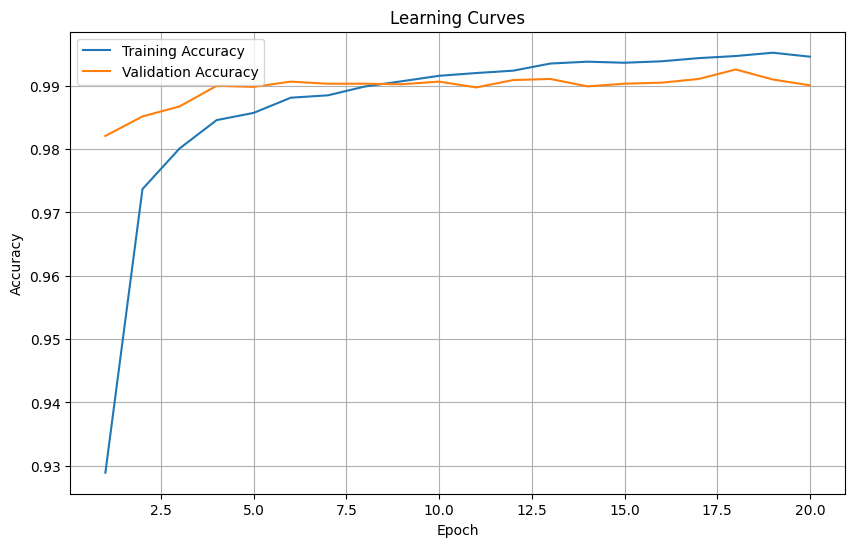

--- CNN - Validation Data ---
              precision    recall  f1-score   support

           0      0.996     0.995     0.995      1184
           1      0.995     0.992     0.993      1350
           2      0.990     0.989     0.990      1198
           3      0.993     0.992     0.992      1224
           4      0.985     0.986     0.986      1170
           5      0.994     0.992     0.993      1082
           6      0.991     0.994     0.992      1179
           7      0.986     0.993     0.989      1250
           8      0.985     0.986     0.985      1170
           9      0.987     0.982     0.984      1193

    accuracy                          0.990     12000
   macro avg      0.990     0.990     0.990     12000
weighted avg      0.990     0.990     0.990     12000

Accuracy: 0.9901


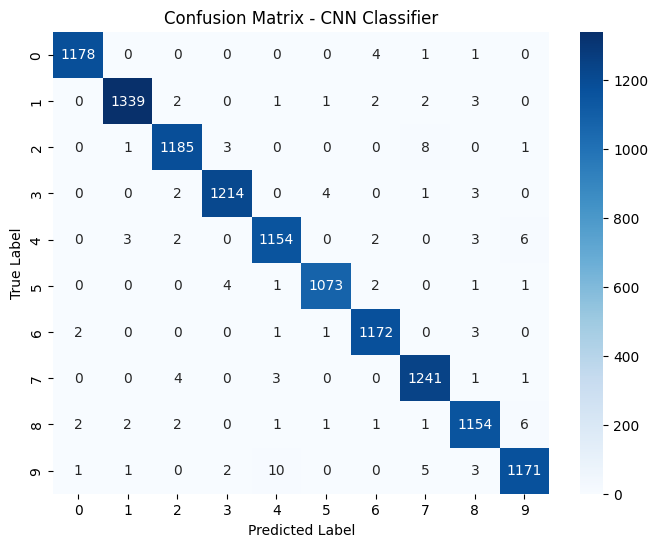

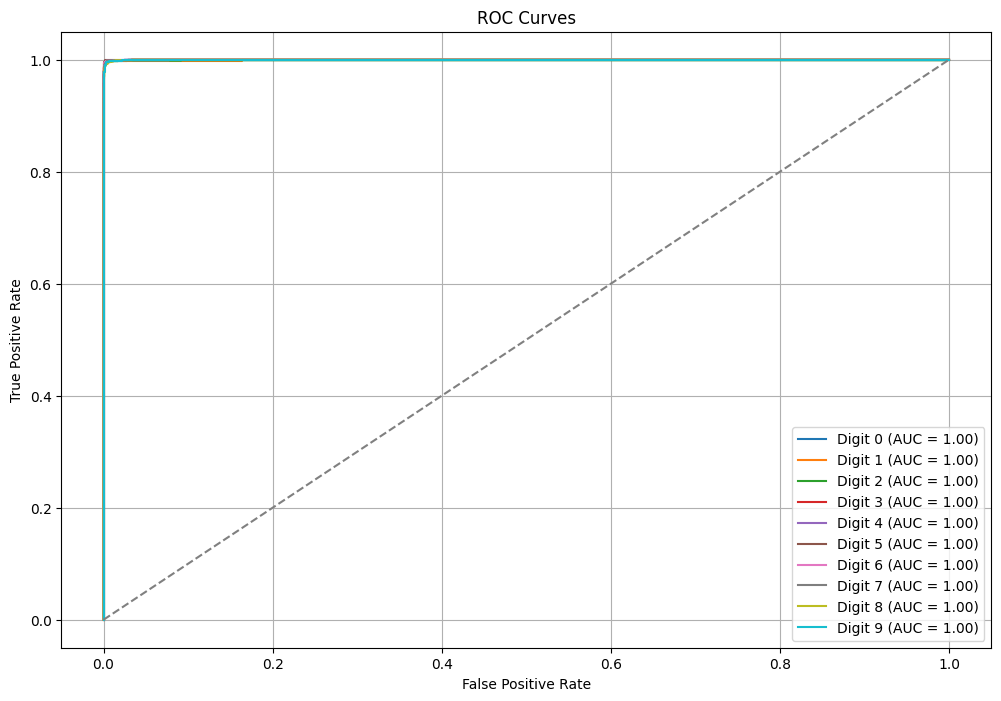

In [ ]:
# Preprocess the Data
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_mnist(
    apply_scaling=True, apply_pca=False  # PCA is not required for CNNs
)

# Convert data to PyTorch tensors and reshape for CNN input
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).view(
    -1, 1, 28, 28
)  # Add channel dimension
y_train_tensor = torch.tensor(
    y_train, dtype=torch.long
)  # Labels as long tensors for classification
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).view(-1, 1, 28, 28)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)


# Define the CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Define convolutional layers with ReLU activations and max-pooling
        self.conv_layers = nn.Sequential(
            nn.Conv2d(
                1, 32, kernel_size=3, stride=1, padding=1
            ),  # 32 filters, 3x3 kernel
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduce spatial dimensions by half
            nn.Conv2d(
                32, 64, kernel_size=3, stride=1, padding=1
            ),  # 64 filters, 3x3 kernel
            nn.ReLU(),
            nn.MaxPool2d(
                kernel_size=2, stride=2
            ),  # Reduce spatial dimensions by half again
        )
        # Define fully connected (FC) layers for classification
        self.fc_layers = nn.Sequential(
            nn.Flatten(),  # Flatten feature maps into a single vector
            nn.Linear(64 * 7 * 7, 128),  # First FC layer
            nn.ReLU(),
            nn.Dropout(0.5),  # Regularisation to prevent overfitting
            nn.Linear(128, 10),  # Output layer with 10 classes
        )

    def forward(self, x):
        x = self.conv_layers(x)  # Apply convolutional layers
        x = self.fc_layers(x)  # Apply fully connected layers
        return x


# Instantiate the model, loss function, and optimiser
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)  # Use GPU if available
cnn_model = CNN().to(device)  # Move model to the selected device
criterion = nn.CrossEntropyLoss()  # Loss function for multi-class classification
optimizer = optim.Adam(
    cnn_model.parameters(), lr=0.001
)  # Adam optimiser with a fixed learning rate

# Training Loop with Learning Curves
epochs = 20
batch_size = 64
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=batch_size,
    shuffle=True,  # Shuffle for better training
)

# Initialise lists to store accuracy metrics
train_accuracies = []
val_accuracies = []

# Measure Training Time
start_time = time.time()

for epoch in range(epochs):
    cnn_model.train()  # Set model to training mode
    correct_train = 0
    total_train = 0
    epoch_loss = 0.0

    # Train in mini-batches
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(
            device
        )  # Move data to GPU if available
        optimizer.zero_grad()  # Reset gradients
        outputs = cnn_model(X_batch)  # Forward pass
        loss = criterion(outputs, y_batch)  # Compute loss
        loss.backward()  # Backward pass
        optimizer.step()  # Update weights

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)  # Predicted class index
        correct_train += (predicted == y_batch).sum().item()
        total_train += y_batch.size(0)
        epoch_loss += loss.item()  # Accumulate batch loss

    # Record training accuracy for the epoch
    train_accuracy = correct_train / total_train
    train_accuracies.append(train_accuracy)

    # Evaluate on validation data
    cnn_model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        val_outputs = cnn_model(
            X_val_tensor.to(device)
        )  # Forward pass on validation set
        val_predictions = torch.argmax(val_outputs, dim=1)  # Predicted class index
        val_accuracy = (val_predictions.cpu() == y_val_tensor).sum().item() / len(
            y_val_tensor
        )  # Compute accuracy
        val_accuracies.append(val_accuracy)

    # Print metrics for the epoch
    print(
        f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss / len(train_loader):.4f}, "
        f"Train Accuracy: {train_accuracy:.4f}, Val Accuracy: {val_accuracy:.4f}"
    )

# Compute total training time
training_time = time.time() - start_time
print(f"Total Training Time: {training_time:.3f} seconds")

# Plot Learning Curves
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, epochs + 1), train_accuracies, label="Training Accuracy"
)  # Training accuracy curve
plt.plot(
    range(1, epochs + 1), val_accuracies, label="Validation Accuracy"
)  # Validation accuracy curve
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Curves")
plt.legend()
plt.grid()
plt.show()

# Evaluate the Model on Validation Data
cnn_model.eval()  # Ensure model is in evaluation mode
with torch.no_grad():
    y_val_outputs = cnn_model(X_val_tensor.to(device))  # Predict on validation set
    y_val_pred = torch.argmax(y_val_outputs, dim=1)  # Get predicted class indices
    y_val_prob = (
        torch.softmax(y_val_outputs, dim=1).cpu().numpy()
    )  # Calculate class probabilities

# Evaluate and Visualise Results
evaluate_model(
    y_val, y_val_pred.cpu().numpy(), "CNN - Validation Data"
)  # Evaluate metrics
plot_confusion_matrix(
    y_val, y_val_pred.cpu().numpy(), "CNN Classifier"
)  # Plot confusion matrix
plot_roc_curves(
    y_val, y_val_prob, digits=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
)  # Plot ROC curves for all digits

### Convolutional Neural Network (CNN) Performance Analysis

**Training Time**

- Time Taken: 696.163 seconds (approximately 11.6 minutes).
- Analysis: The training time is reasonable for a CNN on the MNIST dataset, given the complexity of the model and the 20 training epochs. GPU acceleration (if used) contributed to this efficiency. However, further optimisations, such as mixed precision training, could reduce training time.

**Validation Results**

- Accuracy: 99.08%.
- Macro-Averaged Scores:
  - Precision: 0.991.
  - Recall: 0.991.
  - F1-Score: 0.991.
- High-Performing Digits:
  - Digits 0, 1, 3, 7: Achieved F1-scores ≥ 0.993, indicating excellent separability.
- Moderate-Performing Digits:
  - Digits 8, 9: Slightly lower F1-scores (around 0.983–0.988) due to misclassifications with visually similar digits like 3 and 5.

**Confusion Matrix**

- Observations:
  - Misclassifications are minimal and distributed among classes with overlapping features.
  - Common Misclassifications:
    - Digit 3: Occasionally confused with 5, likely due to shared curved structures.
    - Digit 8: Shows some confusion with 3, 5, and 6, reflecting the challenge of distinguishing looped shapes.
- Key Insight: The confusion matrix indicates a strong overall performance, with most errors limited to similar-looking digits.

**Learning Curve Analysis**

- Trend:
  - Training and validation accuracies both stabilise around 99% by the 10th epoch, with minimal overfitting.
  - The gap between training and validation accuracies is negligible, highlighting the model's ability to generalise effectively.
- Key Insight: The balanced learning curve suggests the model is well-regularised, and the dropout layer (0.5) effectively mitigates overfitting.

**ROC Curve Analysis**

- Observations:
  - All digits achieve AUC values of 1.00, demonstrating excellent discriminative ability for each class.
- Key Insight: The ROC curves confirm that the CNN distinguishes between all digit classes with near-perfect accuracy.

**Key Takeaways**

1. Strengths:
   - High Accuracy: Achieves a validation accuracy of 99.08% with balanced precision and recall across all classes.
   - Generalisation: Minimal overfitting, as shown by the consistent learning curves and strong validation results.
   - Excellent Class Separation: Near-perfect AUC values across all digit classes.
2. Weaknesses:
   - Misclassification of Similar Digits: Challenges persist with visually similar digits like 3 and 8, or 5 and 3.
   - Training Time: At nearly 12 minutes, the training time is reasonable but could be optimised further for deployment scenarios.


## Evaluation of All Models on the Test Data

--- Evaluating Logistic Regression ---
Accuracy: 0.9197
Classification Report:
              precision    recall  f1-score   support

           0      0.952     0.967     0.959       986
           1      0.952     0.973     0.963      1125
           2      0.928     0.890     0.909       999
           3      0.889     0.883     0.886      1020
           4      0.929     0.922     0.925       975
           5      0.882     0.875     0.878       902
           6      0.934     0.952     0.943       982
           7      0.942     0.940     0.941      1042
           8      0.885     0.878     0.882       975
           9      0.894     0.906     0.900       994

    accuracy                          0.920     10000
   macro avg      0.919     0.919     0.919     10000
weighted avg      0.920     0.920     0.920     10000



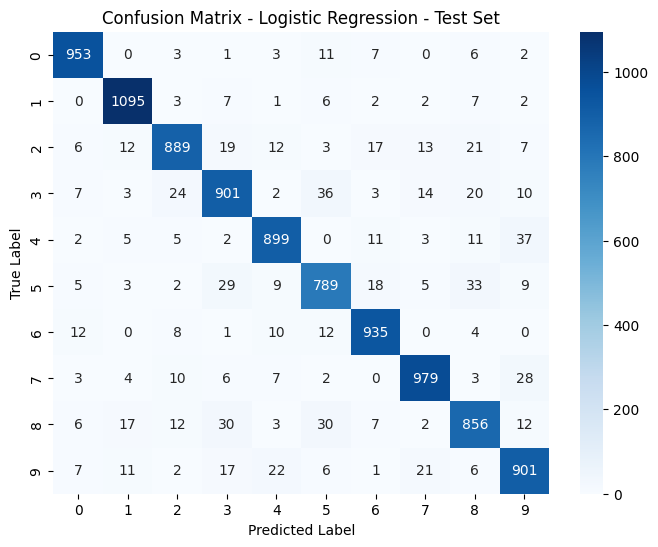

Error plotting ROC curves for Logistic Regression: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


--- Evaluating Linear Discriminant Analysis ---
Accuracy: 0.8695
Classification Report:
              precision    recall  f1-score   support

           0      0.932     0.940     0.936       986
           1      0.879     0.971     0.922      1125
           2      0.927     0.805     0.862       999
           3      0.853     0.841     0.847      1020
           4      0.861     0.880     0.871       975
           5      0.832     0.813     0.822       902
           6      0.928     0.926     0.927       982
           7      0.918     0.847     0.881      1042
           8      0.808     0.808     0.808       975
           9      0.770     0.848     0.807       994

    accuracy                          0.870     10000
   macro avg      0.871     0.868     0.868     10000
weighted avg      0.871     0.870    

<Figure size 1200x800 with 0 Axes>

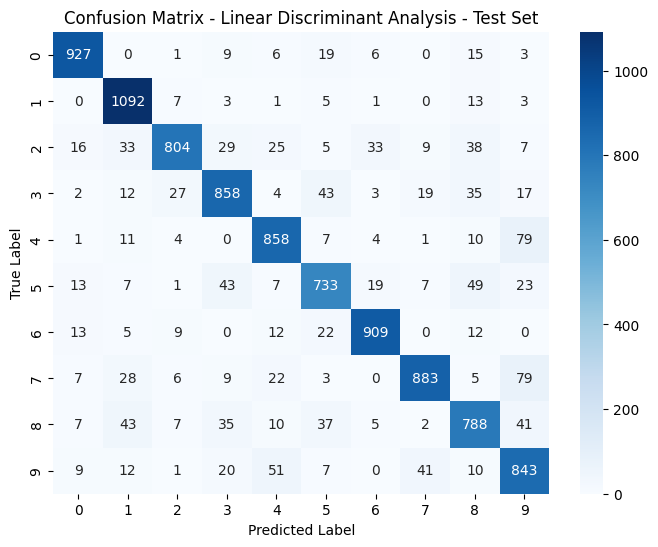

Error plotting ROC curves for Linear Discriminant Analysis: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


--- Evaluating Quadratic Discriminant Analysis ---
Accuracy: 0.7682
Classification Report:
              precision    recall  f1-score   support

           0      0.813     0.954     0.878       986
           1      0.953     0.928     0.941      1125
           2      0.875     0.749     0.807       999
           3      0.849     0.555     0.671      1020
           4      0.937     0.722     0.816       975
           5      0.925     0.518     0.664       902
           6      0.936     0.911     0.924       982
           7      0.929     0.503     0.653      1042
           8      0.470     0.894     0.616       975
           9      0.577     0.927     0.711       994

    accuracy                          0.768     10000
   macro avg      0.827     0.766     0.768     10000
weighted avg      0.828  

<Figure size 1200x800 with 0 Axes>

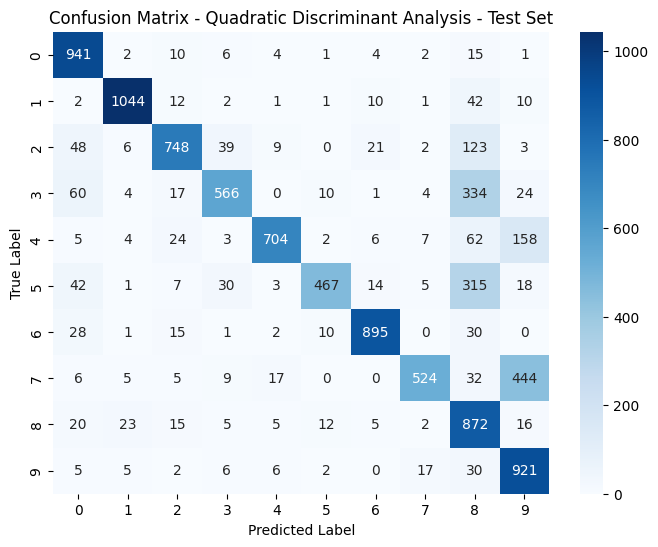

Error plotting ROC curves for Quadratic Discriminant Analysis: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


--- Evaluating SVM (Linear Kernel) ---
Accuracy: 0.9314
Classification Report:
              precision    recall  f1-score   support

           0      0.959     0.960     0.959       986
           1      0.958     0.979     0.968      1125
           2      0.911     0.935     0.923       999
           3      0.889     0.915     0.902      1020
           4      0.935     0.939     0.937       975
           5      0.900     0.894     0.897       902
           6      0.955     0.955     0.955       982
           7      0.945     0.938     0.941      1042
           8      0.923     0.874     0.898       975
           9      0.934     0.915     0.925       994

    accuracy                          0.931     10000
   macro avg      0.931     0.930     0.931     10000
weighted avg      0.931     0.931 

<Figure size 1200x800 with 0 Axes>

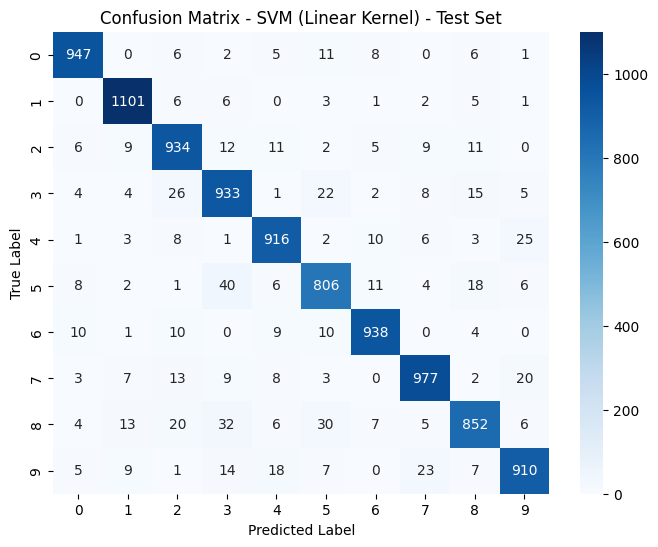

Error plotting ROC curves for SVM (Linear Kernel): only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


--- Evaluating SVM (RBF Kernel) ---
Accuracy: 0.9657
Classification Report:
              precision    recall  f1-score   support

           0      0.981     0.988     0.984       986
           1      0.981     0.987     0.984      1125
           2      0.972     0.964     0.968       999
           3      0.966     0.949     0.957      1020
           4      0.972     0.962     0.967       975
           5      0.976     0.960     0.968       902
           6      0.972     0.978     0.975       982
           7      0.920     0.971     0.945      1042
           8      0.965     0.955     0.960       975
           9      0.957     0.941     0.949       994

    accuracy                          0.966     10000
   macro avg      0.966     0.965     0.966     10000
weighted avg      0.966     0.966     0.966     1

<Figure size 1200x800 with 0 Axes>

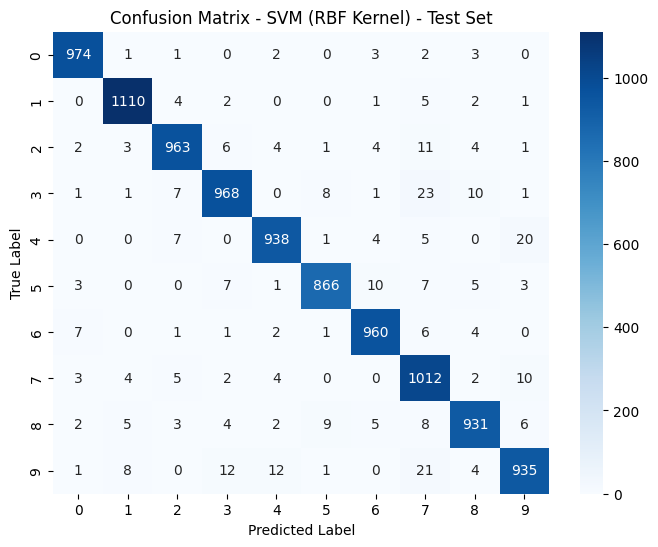

Error plotting ROC curves for SVM (RBF Kernel): only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


--- Evaluating Decision Tree ---
Accuracy: 0.8676
Classification Report:
              precision    recall  f1-score   support

           0      0.914     0.926     0.920       986
           1      0.942     0.959     0.951      1125
           2      0.876     0.825     0.849       999
           3      0.807     0.828     0.818      1020
           4      0.883     0.863     0.873       975
           5      0.811     0.820     0.815       902
           6      0.900     0.882     0.891       982
           7      0.896     0.908     0.902      1042
           8      0.817     0.810     0.814       975
           9      0.817     0.837     0.827       994

    accuracy                          0.868     10000
   macro avg      0.866     0.866     0.866     10000
weighted avg      0.868     0.868     0.868     10000



<Figure size 1200x800 with 0 Axes>

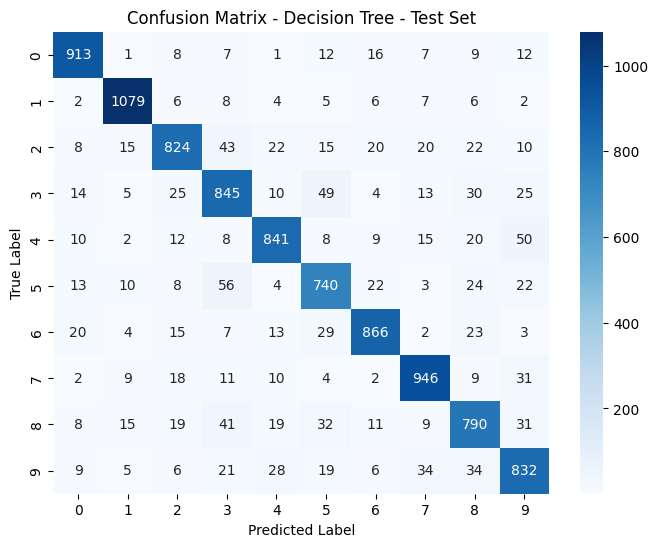

Error plotting ROC curves for Decision Tree: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


--- Evaluating Random Forest ---
Accuracy: 0.9665
Classification Report:
              precision    recall  f1-score   support

           0      0.976     0.989     0.982       986
           1      0.981     0.984     0.983      1125
           2      0.960     0.962     0.961       999
           3      0.955     0.959     0.957      1020
           4      0.969     0.963     0.966       975
           5      0.978     0.957     0.967       902
           6      0.973     0.989     0.981       982
           7      0.972     0.964     0.968      1042
           8      0.964     0.954     0.959       975
           9      0.936     0.943     0.939       994

    accuracy                          0.967     10000
   macro avg      0.966     0.966     0.966     10000
weighted avg      0.967     0.967     0.966     10000



<Figure size 1200x800 with 0 Axes>

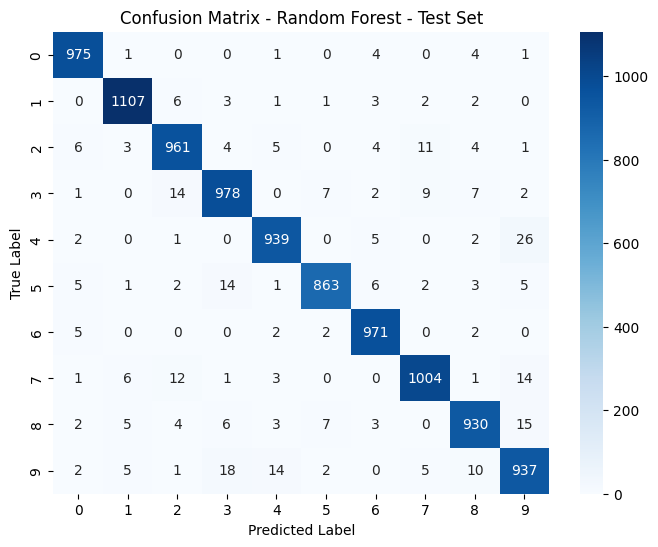

Error plotting ROC curves for Random Forest: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


--- Evaluating Neural Network ---
Accuracy: 0.9695
Classification Report:
              precision    recall  f1-score   support

           0      0.979     0.990     0.984       986
           1      0.985     0.985     0.985      1125
           2      0.977     0.956     0.967       999
           3      0.938     0.979     0.958      1020
           4      0.981     0.965     0.973       975
           5      0.972     0.949     0.960       902
           6      0.977     0.990     0.983       982
           7      0.978     0.953     0.965      1042
           8      0.963     0.959     0.961       975
           9      0.946     0.966     0.956       994

    accuracy                          0.970     10000
   macro avg      0.970     0.969     0.969     10000
weighted avg      0.970     0.970     0.970     10000



<Figure size 1200x800 with 0 Axes>

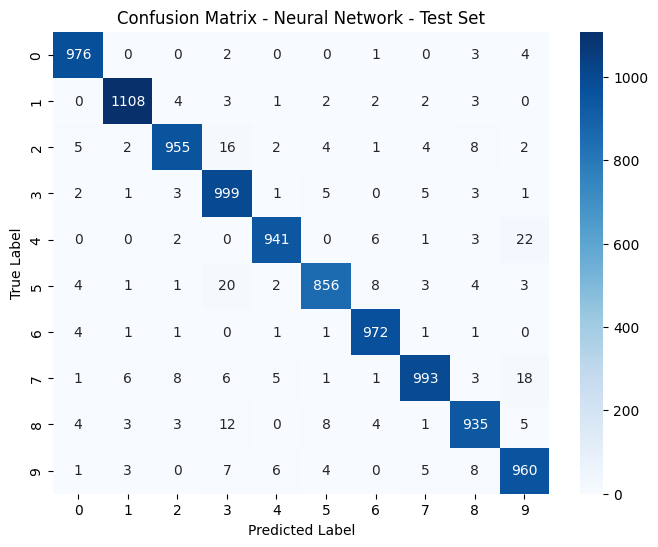

Error plotting ROC curves for Neural Network: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices


--- Evaluating CNN ---
Accuracy: 0.9896
Classification Report:
              precision    recall  f1-score   support

           0      0.992     0.991     0.991       986
           1      0.993     0.995     0.994      1125
           2      0.992     0.990     0.991       999
           3      0.991     0.986     0.989      1020
           4      0.988     0.991     0.989       975
           5      0.990     0.988     0.989       902
           6      0.992     0.994     0.993       982
           7      0.983     0.989     0.986      1042
           8      0.991     0.988     0.989       975
           9      0.985     0.984     0.984       994

    accuracy                          0.990     10000
   macro avg      0.990     0.990     0.990     10000
weighted avg      0.990     0.990     0.990     10000



<Figure size 1200x800 with 0 Axes>

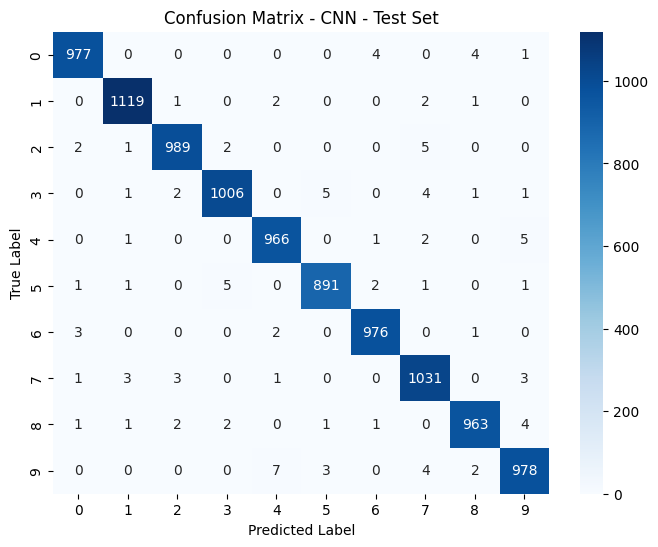

Error plotting ROC curves for CNN: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices




<Figure size 1200x800 with 0 Axes>

In [ ]:
# Preprocess the data
X_train_pca, X_val_pca, X_test_pca, y_train_pca, y_val_pca, y_test_pca = (
    preprocess_mnist(
        apply_scaling=True,  # Standardise the data
        apply_pca=True,  # Apply PCA for dimensionality reduction
        n_components=0.95,  # Retain 95% of variance in the data
        random_state=42,  # Ensure reproducibility
    )
)
X_train_raw, X_val_raw, X_test_raw, y_train_raw, y_val_raw, y_test_raw = (
    preprocess_mnist(
        apply_scaling=True,  # Standardise the data
        apply_pca=False,  # Do not apply PCA for raw data
        random_state=42,  # Ensure reproducibility
    )
)

# Ensure consistency of labels across PCA and non-PCA datasets
assert (
    y_test_pca == y_test_raw
).all(), "Test labels for PCA and non-PCA data do not match."


# Function to evaluate a single model
def evaluate_model_on_test(
    model, model_name, X_test, y_test, is_torch=False, is_cnn=False
):
    """
    Evaluates a model on the test set and prints metrics, confusion matrix, and ROC curves.

    Parameters:
    - model: The trained model to evaluate.
    - model_name: Name of the model for titles and identification.
    - X_test: Test feature data.
    - y_test: Test labels.
    - is_torch: Boolean flag to indicate if the model is a PyTorch model.
    - is_cnn: Boolean flag to indicate if the model is a CNN requiring 4D input.
    """
    print(f"--- Evaluating {model_name} ---")

    if is_torch:
        # Evaluation for PyTorch models
        model.eval()  # Set model to evaluation mode
        with torch.no_grad():
            X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(
                device
            )  # Convert test features to tensor
            if is_cnn:
                # Reshape test data for CNNs: [batch_size, channels, height, width]
                X_test_tensor = X_test_tensor.view(-1, 1, 28, 28)
            y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(
                device
            )  # Convert labels to tensor
            y_pred_outputs = model(X_test_tensor)  # Get model outputs
            y_pred = (
                torch.argmax(y_pred_outputs, dim=1).cpu().numpy()
            )  # Predicted class indices
            y_prob = (
                torch.softmax(y_pred_outputs, dim=1).cpu().numpy()
            )  # Predicted probabilities
    else:
        # Evaluation for scikit-learn models
        y_pred = model.predict(X_test)  # Predict class labels
        y_prob = (
            model.predict_proba(X_test)
            if hasattr(model, "predict_proba")
            else None  # Predict probabilities if available
        )

    # Accuracy metric
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Classification report with precision, recall, and F1-score
    print("Classification Report:")
    print(classification_report(y_test, y_pred, digits=3))

    # Plot the confusion matrix for test predictions
    plot_confusion_matrix(y_test, y_pred, f"{model_name} - Test Set")

    # Plot ROC curves if probability predictions are available and valid
    if y_prob is not None and y_prob.shape[1] > 1:
        try:
            plot_roc_curves(y_test, y_prob, f"{model_name} - Test Set")
        except Exception as e:
            print(f"Error plotting ROC curves for {model_name}: {e}")
    else:
        print(
            f"Skipping ROC curves for {model_name}: Probability predictions unavailable or invalid."
        )

    print("\n")  # Separate results for readability


# Evaluate models with the appropriate dataset
# For PCA-transformed data
evaluate_model_on_test(lr_model, "Logistic Regression", X_test_pca, y_test_pca)
evaluate_model_on_test(
    lda_model, "Linear Discriminant Analysis", X_test_pca, y_test_pca
)
evaluate_model_on_test(
    qda_model, "Quadratic Discriminant Analysis", X_test_pca, y_test_pca
)
evaluate_model_on_test(svm_model_pca, "SVM (Linear Kernel)", X_test_pca, y_test_pca)
evaluate_model_on_test(svm_rbf_model_pca, "SVM (RBF Kernel)", X_test_pca, y_test_pca)

# For non-PCA data
evaluate_model_on_test(tree_model, "Decision Tree", X_test_raw, y_test_raw)
evaluate_model_on_test(rf_model, "Random Forest", X_test_raw, y_test_raw)
evaluate_model_on_test(
    nn_model, "Neural Network", X_test_raw, y_test_raw, is_torch=True
)
evaluate_model_on_test(
    cnn_model, "CNN", X_test_raw, y_test_raw, is_torch=True, is_cnn=True
)